# Novelty-Driven Mean Reversion
### A Portfolio Sort Study of Earnings Call Text (FIN 285F)
**Authoritative steps** follow **`project_specification_rio_zac.pdf`**. This notebook mirrors the memo’s section order; cell headings below cite the PDF §. Where **`FINAL.csv`** lacks turn/component rows, we use **sentence-level** splits on `full_transcript_text` and note the gap explicitly.

### Project steps (PDF → notebook)

1. **§1 Introduction** — Semantic novelty vs a firm’s own past language; overreaction and mean reversion; CMN (2020) benchmark. *Context:* this header and §10.
2. **§2 Research question & hypotheses** — **H1:** long Q1 (low adjusted novelty) / short Q5 (high); **H2:** larger event reaction for Q5 then partial reversal **[+2, +5]**; **H3:** FinBERT positive tone × novelty (optional). *Notebook:* §7 (event paths), §6b (regressions / FF5); H3 when you add FinBERT sorts.
3. **§3 Data sources & definitions** — Returns (`ret_t-15` … `ret_t+15`, overnight), identifiers (`permno`), `full_transcript_text`, and **constructed variables**: embedding novelty, lexical baselines (TF‑IDF / BM25 in memo), salience, LLM gate, SUE, macro penalty, section/analyst/topic weights (staged as data allow). *Notebook:* §1 load; §2–§6 NLP and merges.
4. **§4 Data policy & governance** — Sample rules: earnings calls, non-missing **`permno`**, **`word_count` ≥ 100**, **≥ 2** prior transcripts, **non-missing returns on [−1, +5]**; winsorize returns and overnight at **1st / 99th**; no look-ahead in baselines. *Notebook:* §1b + `nh.apply_project_spec_sample_pipeline` (`SAMPLE_FLOW`).
5. **§5 Exploratory data analysis** — Summary stats, return and text distributions, time coverage. *Notebook:* §1 preview cell; §8 diagnostics (extend with memo-style tables as needed).
6. **§6 Portfolio construction** — Within-quarter **quintiles** on adjusted novelty; **long Q1 / short Q5**; **quarterly** rebalance and holding period per memo; equal-weight baseline. *Notebook:* §7 implements an **event-window / CAR-style supplement** (memo §6.4); full **calendar-time quarterly sort** is the next build to match §6.1–6.3 exactly.
7. **§7 Model specification** — Risk-adjust returns (e.g. **Fama–French 5-factor**), **SUE** and **`pre_drift`** controls, clustered inference. *Notebook:* §6b (`nh.fit_ols_cluster`, FF5).

**Appendices (memo)** — **A** salience clusters → `salience_dictionary.py`; **B** NLP parameters → embedding / threshold config cells; **C** variable definitions → `novelty_helpers.py`; **D** sample construction flow → §1b `SAMPLE_FLOW`.

### NLP execution order (implements §3.3 precision gate + macro)
1. **Lexical baseline (TF‑IDF)** — per-firm rolling profile (memo lexical robustness path; also supports interpretation).
2. **Semantic novelty** — encoder + distance to historical centroid on **turn-aligned** segments (memo primary: **nomic-embed-text-v1.5**; notebook default `all-MiniLM-L6-v2` until swapped).
3. **Salience ≥ 0.30** and **novelty ≥ 0.60** → **Ollama** verbatim §3.3 YES/NO prompt → **LLM = YES** required for gated rows.
4. **Cross-market penalty** — sigmoid in cluster frequency (**f₀=0.40**, **k=15**); notebook uses **quarter × cluster** as proxy until trailing **three-month** prior window is merged (memo §3.3 / §4.4).
5. **Adjusted novelty** → firm-event aggregation and within-quarter **quintiles** for sorts.

> **Embeddings:** Not FinBERT for novelty geometry; memo encoder is **Nomic**; **H3** uses FinBERT **tone** separately.
>
> **Dev runs:** `_DEV_TICKERS_RAW` in §0 → scoped `*__dev_*.pkl` caches; `None` = full panel.


## 0. Environment & Imports

In [97]:
# Install dependencies if needed
# !pip install sentence-transformers scikit-learn pandas numpy statsmodels

import warnings
warnings.filterwarnings("ignore")

import sys, os, re, json, pickle
import importlib.util
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Sentence embeddings — semantic encoder, NOT FinBERT (sentiment classifier)
from sentence_transformers import SentenceTransformer

# Project root: cwd, cwd/final_project, or any parent/*/final_project (robust to Jupyter cwd).
def _final_project_root() -> Path:
    here = Path.cwd().resolve()
    for c in (here, here / "final_project"):
        if (c / "novelty_helpers.py").is_file():
            return c.resolve()
    for base in here.parents:
        fp = base / "final_project" / "novelty_helpers.py"
        if fp.is_file():
            return fp.parent.resolve()
    raise FileNotFoundError(
        "novelty_helpers.py not found — open a terminal in `final_project` or run Jupyter with cwd there."
    )


def _load_novelty_helpers(project_root: Path):
    """Load `novelty_helpers.py` by path so a different package named novelty_helpers cannot shadow it."""
    path = project_root / "novelty_helpers.py"
    spec = importlib.util.spec_from_file_location("novelty_helpers", path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Cannot load {path}")
    mod = importlib.util.module_from_spec(spec)
    sys.modules["novelty_helpers"] = mod
    spec.loader.exec_module(mod)
    return mod


_PROJECT_ROOT = _final_project_root()
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

# Salience dictionary — same directory as novelty_helpers.py
from salience_dictionary import score_sentence, SALIENCE_DICT

if "novelty_helpers" in sys.modules:
    del sys.modules["novelty_helpers"]
nh = _load_novelty_helpers(_PROJECT_ROOT)

# --- Semantic encoder: change only these when moving to Nomic (then delete/rename pickle caches) ---
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"  # later: e.g. "BAAI/bge-small-en-v1.5" if exposed via sentence-transformers
EMBEDDING_CACHE_TAG = "novelty_all_mini"  # bump when novelty geometry/segmentation changes

# Dev: small ticker sample (e.g. 3 names) for fast runs. Uses *__dev_AAPL_MSFT_NVDA.pkl sidecars;
# falls back to slicing the full pickle if a dev file does not exist yet. None = full panel.
_DEV_TICKERS_RAW =  None
# _DEV_TICKERS_RAW =  ("AAPL","MSFT","NVDA") #  None = all rows in top50 below
DEV_TICKERS = nh.dev_tickers_normalized(_DEV_TICKERS_RAW)
# After changing this or the ticker list, re-run: df → turn-index cell → baselines → novelty (pickles are dev-scoped).


def embedding_cache_path(stem: str) -> Path:
    """Pickle path keyed by EMBEDDING_CACHE_TAG so a new encoder does not clobber old caches."""
    cache_dir = Path("./pkl_cache")
    cache_dir.mkdir(parents=True, exist_ok=True)
    if EMBEDDING_CACHE_TAG == "default":
        return cache_dir / f"{stem}.pkl"
    return cache_dir / f"{stem}_{EMBEDDING_CACHE_TAG}.pkl"


print("All imports OK")
print(f"Salience clusters: {len(SALIENCE_DICT)}")
print(f"Embedding model: {EMBEDDING_MODEL_NAME} | cache tag: {EMBEDDING_CACHE_TAG}")
if DEV_TICKERS:
    print(f"DEV_TICKERS={DEV_TICKERS!r} — dev sample mode (scoped cache files)")


All imports OK
Salience clusters: 26
Embedding model: all-MiniLM-L6-v2 | cache tag: novelty_all_mini


## 1. Data load — PDF §3 (sources & definitions)

**PDF §3.1–3.2:** financial fields (daily returns around the call, overnight return, `permno`, event dates) and **text** (`full_transcript_text`). **`FINAL.csv`** is the working extract (~181k calls). The next cell **previews** columns without loading full text; the following cell loads `USE_COLS` via `novelty_helpers` (**returns** `ret_t-15` … `ret_t15`, **I/B/E/S** / SUE, **Compustat** links, **`full_transcript_text`**).

**Not in file:** market capitalization (merge from CRSP/Compustat by `permno`/`gvkey` when you add size controls). **Turn metadata** is merged from **`transcript_speaker_indices.csv`** (same folder as this notebook).

**Vs. prior `aggregated_all_years_updated_event.csv`:** Same column names for every field that existed before; `FINAL.csv` only **adds** Compustat/I-B-E-S link columns (no renames, no dropped core fields). The event panel is **slightly smaller** (stricter sample / merge), so a handful of `transcriptid`s differ from the old file.

**Turn NLP caches:** With `EMBEDDING_CACHE_TAG = "turns"`, novelty/baseline pickles are **`novelty_*_turns.pkl`**; re-run the baseline + novelty cells after changing the ticker panel, `transcript_speaker_indices.csv`, or the encoder.

In [98]:
# Preview FINAL.csv shape & key fields (excludes full_transcript_text for speed)
DATA_PATH = Path(".") / "FINAL.csv"
assert DATA_PATH.exists(), f"Data not found at {DATA_PATH.resolve()}"

RET_COLS = [f"ret_t{j}" for j in list(range(-15, 0)) + list(range(0, 16))]
all_cols = list(pd.read_csv(DATA_PATH, nrows=0).columns)
PREVIEW_COLS = [c for c in all_cols if c != "full_transcript_text"]
prev = pd.read_csv(DATA_PATH, usecols=PREVIEW_COLS, low_memory=False)

print("=== FINAL.csv (metadata / numeric columns only) ===")
print(f"Path:   {DATA_PATH.resolve()}")
print(f"Rows:   {len(prev):,}")
print(f"Cols:   {len(all_cols)} (including full_transcript_text)")
print(f"permno missing:     {prev['permno'].isna().sum():,}")
print(f"ibes_sue_eps nn:    {prev['ibes_sue_eps'].notna().sum():,}  (SUE)")
print(f"ibes_raw_surp nn:   {prev['ibes_raw_surp_eps'].notna().sum():,}")
print(f"ibes_mean_est nn:   {prev['ibes_mean_est_eps'].notna().sum():,}")
wc = prev["word_count"]
print(f"word_count min/median/max: {wc.min()} / {wc.median()} / {wc.max()}")

print("\n--- Column groups ---")
groups = {
    "Identifiers & event": ["transcriptid", "companyid", "headline", "transcriptcreationdate_utc",
                            "mostimportantdateutc", "companyname", "ticker", "event_type", "call_date", "actual_call_date"],
    "Returns & prices": ["permno", "close_price_call_day", "open_price_next_day", "close_to_open_return"] + RET_COLS,
    "Text size": ["transcript_length", "word_count"],
    "Compustat": ["gvkey", "fiscal_period_end", "report_date", "fiscal_year", "fiscal_quarter", "compustat_actual_revenue"],
    "I/B/E/S": [c for c in prev.columns if c.startswith("ibes_")],
}
for label, cols in groups.items():
    hit = [c for c in cols if c in prev.columns]
    if hit:
        print(f"{label}: {', '.join(hit)}")

print("\nNote: turn splits use transcript_speaker_indices.csv (fallback: rough sentence splitter).")
print("Note: Market cap is not in FINAL.csv; add via CRSP/Compustat merge on permno/gvkey for regressions.")

sample_cols = [c for c in ["ticker", "mostimportantdateutc", "permno", "word_count", "ibes_sue_eps",
                           "ibes_raw_surp_eps", "close_to_open_return", "ret_t0", "ret_t1"] if c in prev.columns]
print("\n--- First 3 rows (sample columns) ---")
print(prev[sample_cols].head(3).to_string(index=False))

=== FINAL.csv (metadata / numeric columns only) ===
Path:   /Users/zacgarland/r_projects/wrds/final_project/FINAL.csv
Rows:   181,305
Cols:   60 (including full_transcript_text)
permno missing:     5,287
ibes_sue_eps nn:    136,620  (SUE)
ibes_raw_surp nn:   151,676
ibes_mean_est nn:   151,619
word_count min/median/max: 1 / 6581.0 / 102504

--- Column groups ---
Identifiers & event: transcriptid, companyid, headline, transcriptcreationdate_utc, mostimportantdateutc, companyname, ticker, event_type, call_date, actual_call_date
Returns & prices: permno, close_price_call_day, open_price_next_day, close_to_open_return, ret_t-15, ret_t-14, ret_t-13, ret_t-12, ret_t-11, ret_t-10, ret_t-9, ret_t-8, ret_t-7, ret_t-6, ret_t-5, ret_t-4, ret_t-3, ret_t-2, ret_t-1, ret_t0, ret_t1, ret_t2, ret_t3, ret_t4, ret_t5, ret_t6, ret_t7, ret_t8, ret_t9, ret_t10, ret_t11, ret_t12, ret_t13, ret_t14, ret_t15
Text size: transcript_length, word_count
Compustat: gvkey, fiscal_period_end, report_date, fiscal_year,

In [99]:
DATA_PATH = Path(".") / "FINAL.csv"
assert DATA_PATH.exists(), f"Data not found at {DATA_PATH.resolve()}"

print("Loading FINAL.csv via nh.load_and_clean_final_csv (column list in novelty_helpers.py)...")
raw = nh.load_and_clean_final_csv(DATA_PATH)
print(f"After load + basic text clean: {raw.shape}")


Loading FINAL.csv via nh.load_and_clean_final_csv (column list in novelty_helpers.py)...
After load + basic text clean: (181296, 57)


## 1b. Sample construction — PDF §4 (data policy)

**PDF §4.1–4.3:** **non-missing `permno`**, **`word_count` ≥ 100**, **≥ 2 prior transcripts** per firm (strictly earlier quarters), **non-missing returns on [−1, +5]** (`ret_t-1` … `ret_t5`); **winsorize** those dailies and **`close_to_open_return`** at **1st / 99th** (pooled on the kept sample). **`pre_drift`** and **`sue`** are prepared for §7 controls.

Also adds **`pre_drift`** = sum(`ret_t-15` … `ret_t-1`) when all fifteen are non-missing (otherwise NaN — does not drop rows). Renames **`sue`** ← `ibes_sue_eps` for regressions later.

In [100]:
# Project-spec sample + winsorize + pre_drift + sue (implementation: novelty_helpers)
raw, SAMPLE_FLOW = nh.apply_project_spec_sample_pipeline(raw)
print(SAMPLE_FLOW.to_string(index=False))
print(f"\npre_drift non-missing: {raw['pre_drift'].notna().sum():,} / {len(raw):,}")
print(f"\nFinal panel for downstream filter: {raw.shape[0]:,} rows × {raw.shape[1]} cols")

                                   Step      N  Lost_vs_prev_step
            Start (after §1 text clean) 181296                NaN
                    Drop missing permno 176009             5287.0
                  Drop word_count < 100 176008                1.0
Keep ≥2 prior transcripts (same ticker) 163416            12592.0
  Drop if any ret in [t-1, t+5] missing 163151              265.0

pre_drift non-missing: 162,964 / 163,151

Final panel for downstream filter: 163,151 rows × 59 cols


In [101]:
# Top-50 S&P 500 by index weight — heavy NLP scope
import yfinance as yf          # or use a hardcoded list if offline
try:
    import pandas_datareader as pdr
    sp500 = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")[0]
    top50_tickers = sp500["Symbol"].head(50).tolist()
except Exception:
    # Fallback hardcoded top-50 as of 2024 (by weight)
    print('using fallback top 50')
    top50_tickers = [
        "AAPL","MSFT","NVDA","AMZN","META","GOOGL","GOOG","BRK-B","LLY","AVGO",
        "JPM","TSLA","UNH","V","XOM","MA","JNJ","PG","HD","MRK","COST","ABBV",
        "BAC","CRM","CVX","WFC","AMD","NFLX","KO","PEP","ORCL","TMO","ACN","LIN",
        "MCD","ABT","PM","GE","IBM","QCOM","DHR","AMGN","CAT","GS","INTC","ISRG",
        "SPGI","VZ","BLK","SCHW"
    ]


df = raw[raw["ticker"].isin(top50_tickers)].copy()
df = df.sort_values(["ticker", "quarter"]).reset_index(drop=True)

if DEV_TICKERS:
    _n0 = len(df)
    df = df[df["ticker"].str.upper().isin(DEV_TICKERS)].copy()
    print(f"DEV_TICKERS filter: kept {len(df):,} / {_n0:,} rows for {DEV_TICKERS!r}")
    if df.empty:
        raise ValueError(f"{DEV_TICKERS!r} not in top-50 subset — check ticker or disable dev mode")

print(f"Top-50 corpus: {df.shape[0]:,} transcripts, {df['ticker'].nunique()} firms")
print(f"Date range: {df['quarter'].min()} → {df['quarter'].max()}")


using fallback top 50
Top-50 corpus: 2,347 transcripts, 43 firms
Date range: 2010Q2 → 2024Q4


## 2. Lexical baseline (TF-IDF) — PDF §3.3 lexical / Cohen et al. analog

Build a TF-IDF vocabulary profile for each firm using all transcripts *before* a given quarter. This defines what is **normal** for that firm linguistically.

The rolling approach means: for each firm-quarter observation, the baseline is everything the firm has said in prior quarters. We store top-N terms per firm-quarter as the baseline fingerprint.


In [102]:
def clean_text(txt: str) -> str:
    """Strip operator boilerplate and safe-harbour preambles."""
    txt = re.sub(r"\[Operator Instructions\]", "", txt, flags=re.I)
    txt = re.sub(r"(?i)forward.looking statements.{0,200}filings\.", "", txt)
    txt = re.sub(r"\s+", " ", txt)
    return txt.strip()

def split_sentences(txt: str) -> list[str]:
    """Rough sentence splitter (fallback when turn metadata is missing)."""
    sents = re.split(r"(?<=[.!?])\s+(?=[A-Z\"'(\[])", txt)
    return [s.strip() for s in sents if len(s.strip()) > 20]

SPEAKER_INDICES_CSV = _PROJECT_ROOT / "transcript_speaker_indices.csv"

# Build raw per-turn table (source of truth) for the current panel
raw_turn_df = nh.build_raw_turn_table(df, SPEAKER_INDICES_CSV)
print(f"Raw turns: {len(raw_turn_df):,} rows across {raw_turn_df['transcriptid'].nunique():,} transcripts")

# Derive (A) analyst attention per call (no lookahead) and (B) exec-scored chunks
analyst_attn = nh.analyst_attention_features_per_call(raw_turn_df)
exec_chunks = nh.build_exec_chunks(raw_turn_df)
print(f"Exec chunks: {len(exec_chunks):,} rows across {exec_chunks['transcriptid'].nunique():,} transcripts")

# Join attention back onto df for later firm-quarter regressions (optional)
df = df.merge(analyst_attn, on='transcriptid', how='left')

# Rolling analyst attention by topic (trailing ~3 months, no lookahead)
# 1) attach call dates onto raw turns
_call_dates = df[['transcriptid','mostimportantdateutc']].drop_duplicates('transcriptid')
_call_dates['mostimportantdateutc'] = pd.to_datetime(_call_dates['mostimportantdateutc'], errors='coerce')
raw_turn_df = raw_turn_df.merge(_call_dates, on='transcriptid', how='left')

# 2) score analyst turns to get dominant cluster (use salience dictionary)
analyst_turns = raw_turn_df[raw_turn_df['speakertypename'].astype(str) == 'Analysts'].copy()
analyst_turns = analyst_turns.dropna(subset=['mostimportantdateutc','transcriptpersonname','turn_text'])
analyst_turns = analyst_turns[['transcriptid','mostimportantdateutc','transcriptpersonname','turn_text']].copy()

def _dominant_cluster(text: str):
    score, breakdown = score_sentence(str(text)[:2000])
    if not breakdown:
        return None
    return max(breakdown, key=breakdown.get)

if len(analyst_turns):
    analyst_turns['top_cluster'] = analyst_turns['turn_text'].apply(_dominant_cluster)
    analyst_turns = analyst_turns.dropna(subset=['top_cluster'])
    # one row per (call, analyst, cluster)
    analyst_turns = analyst_turns.drop_duplicates(['transcriptid','transcriptpersonname','top_cluster'])
    analyst_turns = nh.rolling_unique_analysts_by_cluster(
        analyst_turns,
        date_col='mostimportantdateutc',
        cluster_col='top_cluster',
        analyst_col='transcriptpersonname',
        window_days=90,
        out_col='trailing_unique_analysts_90d',
    )
    analyst_roll = (
        analyst_turns.groupby(['transcriptid','top_cluster'], sort=False)['trailing_unique_analysts_90d']
        .max()
        .reset_index()
    )
else:
    analyst_roll = pd.DataFrame(columns=['transcriptid','top_cluster','trailing_unique_analysts_90d'])

# Fast lookup: transcriptid → list of exec chunk texts
CHUNKS_BY_TID = (
    exec_chunks.sort_values(['transcriptid','chunk_index'], kind='mergesort')
    # Score on full chunk (operator/analyst context + executive response)
    .groupby('transcriptid')['chunk_text']
    .apply(list)
    .to_dict()
)

# Parallel lookups for debugging / display
EXEC_TEXT_BY_TID = (
    exec_chunks.sort_values(['transcriptid','chunk_index'], kind='mergesort')
    .groupby('transcriptid')['exec_text']
    .apply(list)
    .to_dict()
)
CONTEXT_TEXT_BY_TID = (
    exec_chunks.sort_values(['transcriptid','chunk_index'], kind='mergesort')
    .groupby('transcriptid')['context_text']
    .apply(list)
    .to_dict()
)

# Mapping for: novelty on EXEC *turns* → salience/LLM on full chunk_text
# (exec_chunks has one row per executive answer; we keep the exec turn index.)
_exec_chunk_map = exec_chunks[['transcriptid','chunk_index','exec_turn_index','chunk_text','exec_text']].copy()
_exec_chunk_map['transcriptid'] = _exec_chunk_map['transcriptid'].astype(int)
_exec_chunk_map['chunk_index'] = _exec_chunk_map['chunk_index'].astype(int)
_exec_chunk_map['exec_turn_index'] = _exec_chunk_map['exec_turn_index'].astype(int)
_exec_chunk_map = _exec_chunk_map.sort_values(['transcriptid','chunk_index'], kind='mergesort')

# transcriptid → list of exec turn_texts (one per chunk)
EXEC_TURN_TEXT_BY_TID = _exec_chunk_map.groupby('transcriptid')['exec_text'].apply(list).to_dict()
# transcriptid → list of full chunk_texts aligned to exec turns
CHUNK_TEXT_BY_EXEC_TURN_BY_TID = _exec_chunk_map.groupby('transcriptid')['chunk_text'].apply(list).to_dict()
# transcriptid → list of chunk_index aligned to exec turns
CHUNK_INDEX_BY_EXEC_TURN_BY_TID = _exec_chunk_map.groupby('transcriptid')['chunk_index'].apply(list).to_dict()

# transcriptid → list of ALL raw turn texts (Operator/Analyst/Executive) in turn_index order
FULL_TURNS_BY_TID = (
    raw_turn_df.sort_values(['transcriptid','turn_index'], kind='mergesort')
    .groupby('transcriptid')['turn_text']
    .apply(list)
    .to_dict()
)


def transcript_segments(txt: str, transcriptid: int, *, min_chars: int = 20) -> list[str]:
    """Return exec-scored chunks (operator/analyst context + exec turn).

    Falls back to rough sentence split only if transcriptid has no chunks.
    """
    segs = CHUNKS_BY_TID.get(int(transcriptid))
    if segs:
        return [s for s in segs if len(str(s).strip()) > min_chars]
    return split_sentences(clean_text(str(txt)))


Raw turns: 158,393 rows across 2,347 transcripts
Exec chunks: 78,591 rows across 2,343 transcripts


In [103]:
# Build rolling per-firm TF-IDF baselines
# For each (ticker, quarter), fit TF-IDF on ALL prior quarters of that firm.

print("Building per-firm rolling TF-IDF baselines...")

MAIN_BASELINE_CACHE = embedding_cache_path("novelty_baselines")
BASELINE_CACHE = nh.dev_scoped_cache_path(MAIN_BASELINE_CACHE, DEV_TICKERS)
if DEV_TICKERS:
    print(f"  Baseline pickle: {BASELINE_CACHE.name} (dev) | main: {MAIN_BASELINE_CACHE.name}")

if BASELINE_CACHE.exists():
    with open(BASELINE_CACHE, "rb") as f:
        firm_baselines = pickle.load(f)
    print(f"Loaded cached baselines: {len(firm_baselines)} firm-quarter pairs")
elif DEV_TICKERS and MAIN_BASELINE_CACHE.exists():
    with open(MAIN_BASELINE_CACHE, "rb") as f:
        firm_baselines = nh.filter_baseline_dict(pickle.load(f), DEV_TICKERS)
    print(
        f"Loaded main cache + DEV filter: {len(firm_baselines)} keys for {DEV_TICKERS!r} "
        f"(from {MAIN_BASELINE_CACHE.name})"
    )
else:
    firm_baselines = {}   # key: (ticker, quarter_str) → TfidfVectorizer fitted on prior docs

    for ticker, grp in df.groupby("ticker"):
        quarters = sorted(grp["quarter_str"].unique())

        # Need at least 2 quarters of history before we can compute novelty
        for i, q in enumerate(quarters):
            if i < 2:
                continue   # skip first 2 quarters — not enough history

            prior_qs  = quarters[:i]
            prior_txt = grp[grp["quarter_str"].isin(prior_qs)]["full_transcript_text"].tolist()
            prior_txt = [clean_text(t) for t in prior_txt]

            if len(prior_txt) == 0:
                continue

            vec = TfidfVectorizer(
                max_features   = 3000,
                ngram_range    = (1, 2),
                min_df         = 1,
                stop_words     = "english",
                sublinear_tf   = True,
            )
            try:
                vec.fit(prior_txt)
                firm_baselines[(ticker, q)] = {
                    "vectorizer": vec,
                    "n_docs"    : len(prior_txt),
                    "vocab_size": len(vec.vocabulary_),
                }
            except Exception as e:
                pass

    with open(BASELINE_CACHE, "wb") as f:
        pickle.dump(firm_baselines, f)

    print(f"Built {len(firm_baselines)} firm-quarter baselines → wrote {BASELINE_CACHE.name}")

if nh.dev_mode_active(DEV_TICKERS):
    firm_baselines = nh.filter_baseline_dict(firm_baselines, DEV_TICKERS)
    print(f"  In-memory baselines after DEV guard: {len(firm_baselines)} keys")


Building per-firm rolling TF-IDF baselines...
Loaded cached baselines: 2245 firm-quarter pairs


In [104]:
# Quick sanity check — inspect NVDA baseline
sample_key = [k for k in firm_baselines if k[0] == "NVDA"]
if sample_key:
    k = sorted(sample_key)[-1]
    bl = firm_baselines[k]
    print(f"NVDA baseline at {k[1]}:")
    print(f"  Trained on {bl['n_docs']} prior transcripts")
    print(f"  Vocabulary size: {bl['vocab_size']:,} terms")
    top_terms = sorted(bl['vectorizer'].vocabulary_.items(), key=lambda x: x[1], reverse=True)[:20]
    print(f"  Sample vocab: {[t for t,_ in top_terms[:20]]}")


NVDA baseline at 2024Q4:
  Trained on 57 prior transcripts
  Vocabulary size: 3,000 terms
  Sample vocab: ['yields', 'yield', 'yeung', 'yesterday', 'yes thanks', 'yes', 'years ve', 'years ago', 'years', 'year yes', 'year year', 'year think', 'year tegra', 'year strong', 'year sequentially', 'year revenue', 'year question', 'year ll', 'year just', 'year growth']


## 3. Semantic novelty (embeddings) — PDF §3.3 primary path

For each firm-quarter, embed the **new** transcript **turns** (or sentence fallback) using **`EMBEDDING_MODEL_NAME`** (set in the imports cell) and compare them against the **historical segment centroid** for that firm. Pickle caches are named via **`embedding_cache_path(...)`** (`EMBEDDING_CACHE_TAG` includes **`turns`** for this segmentation).

**Novelty Score** = 1 − cosine_similarity(new_segment, historical_centroid)

A score near 1.0 means the segment is semantically far from anything the firm has said historically. A score near 0 means it's the usual language.

> Default `all-MiniLM-L6-v2` is a strong general sentence encoder for cosine-distance novelty. **Nomic** (`nomic-embed-text-v1.5`) is the project-spec target; when you switch, set `EMBEDDING_MODEL_NAME`, set `EMBEDDING_CACHE_TAG` to a new label (e.g. `nomic_v15`), and rebuild caches. Do **not** use FinBERT *embeddings* for this step (sentiment geometry); FinBERT is reserved for optional **H3** tone sorts later.


In [105]:
# Load sentence encoder — once, shared across all calls
print("Loading sentence encoder...")
ENCODER = SentenceTransformer(EMBEDDING_MODEL_NAME, trust_remote_code = True)
print(f"Model loaded: {EMBEDDING_MODEL_NAME}")


Loading sentence encoder...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: all-MiniLM-L6-v2


In [106]:
# --- Novelty geometry (single mode per run) ---
# Modes:
# - chunk: novelty on full chunk_text (context + exec)
# - turns: novelty on EXEC turns (exec_text), while downstream uses full chunk_text
# - full_turns: novelty on ALL raw speaker turns (Operator/Analyst/Executive turn_text)
NOVELTY_PRIMARY_MODE = "full_turns"  # "turns" | "chunk" | "full_turns"


def _novelty_cache_path_for(mode: str) -> Path:
    base = embedding_cache_path(f"novelty_scores_{mode}")
    return nh.dev_scoped_cache_path(base, DEV_TICKERS)


def _compute_novelty_records_for(mode: str) -> list[dict]:
    assert mode in ("chunk", "turns", "full_turns")
    novelty_cache = _novelty_cache_path_for(mode)
    if DEV_TICKERS:
        print(f"  Novelty pickle ({mode}): {novelty_cache.name}")

    if novelty_cache.exists():
        with open(novelty_cache, "rb") as f:
            recs = pickle.load(f)
        print(f"Loaded {len(recs):,} cached novelty records ({mode})")
        return nh.filter_novelty_records(recs, DEV_TICKERS) if nh.dev_mode_active(DEV_TICKERS) else recs

    novelty_records: list[dict] = []
    firm_historical_embeddings: dict[str, np.ndarray] = {}

    for ticker, grp in df.groupby("ticker"):
        grp = grp.sort_values("quarter")
        quarters_sorted = sorted(grp["quarter_str"].unique().tolist())

        for i, q in enumerate(quarters_sorted):
            if i < 2:
                hist_rows = grp[grp["quarter_str"] == q]
                for _, row in hist_rows.iterrows():
                    tid = int(row["transcriptid"])
                    if mode == "chunk":
                        segs_score = transcript_segments(row["full_transcript_text"], tid)[:60]
                        segs_score = [s for s in segs_score if len(str(s).strip()) > 20]
                    elif mode == "turns":
                        segs_score = EXEC_TURN_TEXT_BY_TID.get(tid) or []
                        segs_score = [s for s in segs_score if len(str(s).strip()) > 20][:60]
                    elif mode == "full_turns":
                        # Score on every raw turn (Operator/Analyst/Executive)
                        segs_score = FULL_TURNS_BY_TID.get(tid) or []
                        segs_score = [s for s in segs_score if len(str(s).strip()) > 20][:200]
                    else:
                        raise ValueError(f"unknown mode={mode!r}")
                    if not segs_score:
                        continue
                    embs = ENCODER.encode(
                        segs_score,
                        batch_size=64,
                        normalize_embeddings=True,
                        show_progress_bar=False,
                    )
                    firm_historical_embeddings[ticker] = (
                        embs if ticker not in firm_historical_embeddings else np.vstack([firm_historical_embeddings[ticker], embs])
                    )
                continue

            if ticker not in firm_historical_embeddings:
                continue

            hist_embs = firm_historical_embeddings[ticker]
            centroid = normalize(hist_embs.mean(axis=0, keepdims=True))

            new_rows = grp[grp["quarter_str"] == q]
            for _, row in new_rows.iterrows():
                tid = int(row["transcriptid"])

                if mode == "chunk":
                    segs_score = transcript_segments(row["full_transcript_text"], tid)[:80]
                    segs_score = [s for s in segs_score if len(str(s).strip()) > 20]
                    segs_full = segs_score
                    seg_idx = list(range(len(segs_full)))

                elif mode == "turns":
                    # Joint filter to keep exec/chunk/index aligned (gate on exec_text only)
                    _all_exec = EXEC_TURN_TEXT_BY_TID.get(tid) or []
                    _all_chunk = CHUNK_TEXT_BY_EXEC_TURN_BY_TID.get(tid) or []
                    _all_idx = CHUNK_INDEX_BY_EXEC_TURN_BY_TID.get(tid) or []
                    _triples = [
                        (ex, ch, ci)
                        for ex, ch, ci in zip(_all_exec, _all_chunk, _all_idx)
                        if len(str(ex).strip()) > 20
                    ][:80]
                    if not _triples:
                        continue
                    segs_score, segs_full, seg_idx = map(list, zip(*_triples))
                    seg_idx = [int(x) for x in seg_idx]

                elif mode == "full_turns":
                    segs_score = FULL_TURNS_BY_TID.get(tid) or []
                    segs_score = [s for s in segs_score if len(str(s).strip()) > 20][:200]
                    segs_full = segs_score
                    seg_idx = list(range(len(segs_full)))

                else:
                    raise ValueError(f"unknown mode={mode!r}")

                if not segs_score:
                    continue

                new_embs = ENCODER.encode(
                    segs_score,
                    batch_size=64,
                    normalize_embeddings=True,
                    show_progress_bar=False,
                )

                sims = cosine_similarity(new_embs, centroid).flatten()
                novelty = 1.0 - sims

                for idx, (sent_full, nov, sim) in enumerate(zip(segs_full, novelty, sims)):
                    novelty_records.append({
                        "ticker": ticker,
                        "quarter_str": q,
                        "fiscal_year": row["fiscal_year"],
                        "transcriptid": row["transcriptid"],
                        "close_to_open_return": row.get("close_to_open_return", np.nan),
                        "sentence": sent_full,
                        "chunk_index": int(seg_idx[idx]),
                        "novelty_score": float(nov),
                        "cosine_sim": float(sim),
                        "novelty_mode": mode,
                    })

                firm_historical_embeddings[ticker] = np.vstack([hist_embs, new_embs])

    with open(novelty_cache, "wb") as f:
        pickle.dump(novelty_records, f)
    print(f"Computed {len(novelty_records):,} novelty rows ({mode}) → wrote {novelty_cache.name}")
    return nh.filter_novelty_records(novelty_records, DEV_TICKERS) if nh.dev_mode_active(DEV_TICKERS) else novelty_records


novelty_records = _compute_novelty_records_for(NOVELTY_PRIMARY_MODE)
novelty_df = pd.DataFrame(novelty_records)
print(f"Novelty ({NOVELTY_PRIMARY_MODE})", novelty_df.shape)
print(novelty_df[["ticker", "quarter_str", "novelty_score"]].describe())


Loaded 147,026 cached novelty records (full_turns)
Novelty (full_turns) (147026, 10)
       novelty_score
count  147026.000000
mean        0.530047
std         0.142312
min         0.173201
25%         0.422357
50%         0.506821
75%         0.625817
max         1.059888


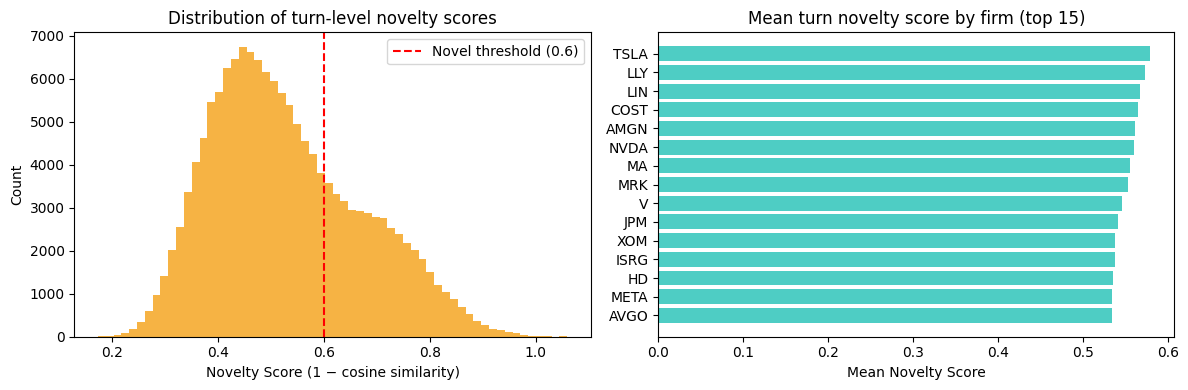

Saved novelty_distribution.png


In [107]:
# Distribution of novelty scores
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
axes[0].hist(novelty_df["novelty_score"], bins=60, color="#f5a623", edgecolor="none", alpha=0.85)
axes[0].set_title("Distribution of turn-level novelty scores", fontsize=12)
axes[0].set_xlabel("Novelty Score (1 − cosine similarity)")
axes[0].set_ylabel("Count")
axes[0].axvline(0.6, color="red", linestyle="--", label="Novel threshold (0.6)")
axes[0].legend()

# By firm — top 15 most novel firms on average
firm_avg = (novelty_df.groupby("ticker")["novelty_score"]
            .mean()
            .sort_values(ascending=False)
            .head(15))
axes[1].barh(firm_avg.index[::-1], firm_avg.values[::-1], color="#4ecdc4")
axes[1].set_title("Mean turn novelty score by firm (top 15)", fontsize=12)
axes[1].set_xlabel("Mean Novelty Score")

plt.tight_layout()
plt.savefig("novelty_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved novelty_distribution.png")


## 4. Salience + LLM intent filter — PDF §3.3 Stage 1 (precision gate)

A high novelty score confirms the firm is discussing something *new* — but not whether it matters financially. A novel turn about litigation, regulatory disclosure, or a CEO aside would all score as novel.

We apply the **salience dictionary** to high-novelty **segments** (turn text in the `sentence` column) to verify that the novel content is a genuine business catalyst. The dictionary scores text across 26 financial clusters (guidance, earnings performance, revenue growth, new products, partnerships, etc.) — a strong proxy for the LLM binary intent filter described in the strategy paper.

**Ollama (local LLM)** uses the **verbatim YES/NO prompt** from **`project_specification_rio_zac.pdf`** §3.3 (financial materiality vs routine call language; exclusions for boilerplate and purely retrospective results). Cache stem: **`llm_intent_cache_project_spec_turns.pkl`** (sentence-split runs used `llm_intent_cache_project_spec.pkl`).

**Signal criteria:**
- `novelty_score ≥ 0.60` — semantically distant from firm's historical baseline
- `salience_score ≥ 0.30` — meaningful financial content, not boilerplate

**Ollama:** Start or restart the local API (default `127.0.0.1:11434`):

- **Terminal:** from `final_project`, run `bash scripts/ensure_ollama.sh`.
- **Notebook:** in the **next** code cell, set `ENSURE_OLLAMA = True` and run it once (it runs the same script via `subprocess`; kills the listener on `OLLAMA_PORT` then starts `ollama serve`). Leave `False` if the menu-bar app already serves the API.

Override with env vars `OLLAMA_HOST`, `OLLAMA_PORT`, or `OLLAMA_URL` if needed. Pull your model once: `ollama pull llama3.1` (or match `OLLAMA_MODEL`).


In [108]:
import subprocess
from pathlib import Path

# True = run scripts/ensure_ollama.sh (stops listener on OLLAMA_PORT, starts `ollama serve`).
# False = assume Ollama is already up (e.g. menu bar app on 11434).
ENSURE_OLLAMA = True

def _run_ensure_ollama_script() -> None:
    root = Path(".").resolve()
    script = root / "scripts" / "ensure_ollama.sh"
    if not script.is_file():
        print(f"Missing {script} (cwd={root})")
        return
    try:
        r = subprocess.run(
            ["bash", str(script)],
            cwd=str(root),
            capture_output=True,
            text=True,
            timeout=120,
        )
    except subprocess.TimeoutExpired:
        print("ensure_ollama.sh timed out after 120s")
        return
    if r.stdout.strip():
        print(r.stdout.rstrip())
    if r.stderr.strip():
        print(r.stderr.rstrip())
    if r.returncode != 0:
        print(f"ensure_ollama.sh exit code {r.returncode}")
    else:
        print("ensure_ollama.sh completed.")

if ENSURE_OLLAMA:
    _run_ensure_ollama_script()

Ollama: stopping anything listening on 127.0.0.1:11434 ...
Ollama: starting `ollama serve` (log: /var/folders/fj/plbn4w9d6fs55651zh_pxsd80000gn/T//ollama-serve.log) ...
Ollama: ready at http://127.0.0.1:11434
  Notebook: OLLAMA_URL = "http://127.0.0.1:11434/api/generate"
ensure_ollama.sh completed.


In [109]:
import os
import time
import requests, json

# Default matches `ollama serve` (run: bash scripts/ensure_ollama.sh from final_project/)
OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "127.0.0.1")
OLLAMA_PORT = os.environ.get("OLLAMA_PORT", "11434")
OLLAMA_URL = os.environ.get(
    "OLLAMA_URL",
    f"http://{OLLAMA_HOST}:{OLLAMA_PORT}/api/generate",
)
OLLAMA_MODEL = os.environ.get("OLLAMA_MODEL", "llama3.1")

print(f"Ollama API: {OLLAMA_URL} | model: {OLLAMA_MODEL}")

# Overnight-friendly: retries, long read timeout, periodic cache checkpoints (resume by re-running this cell).
OLLAMA_HTTP_TIMEOUT = float(os.environ.get("OLLAMA_HTTP_TIMEOUT", "120"))  # full request; local gen can be slow
OLLAMA_MAX_RETRIES = int(os.environ.get("OLLAMA_MAX_RETRIES", "8"))
OLLAMA_RETRY_BASE_SEC = float(os.environ.get("OLLAMA_RETRY_BASE_SEC", "2.0"))
OLLAMA_RETRY_MAX_SLEEP = float(os.environ.get("OLLAMA_RETRY_MAX_SLEEP", "120"))
LLM_CACHE_SAVE_EVERY = int(os.environ.get("LLM_CACHE_SAVE_EVERY", "25"))  # disk write after this many *new* API answers
_ollama_session = requests.Session()

# Thresholds match `project_specification_rio_zac.pdf` §3.3 Stage 1 (precision gate).
NOVELTY_THRESHOLD  = 0.20
SALIENCE_THRESHOLD = 0.30

# Cache stem tied to verbatim PDF prompt; bump filename if §3.3 prompt changes.
LLM_INTENT_CACHE = nh.dev_scoped_cache_path(Path("./pkl_cache/llm_intent_cache_project_spec_turns.pkl"), DEV_TICKERS)
if DEV_TICKERS:
    print(f"  LLM intent cache: {LLM_INTENT_CACHE.name}")

def _parse_llm_yes_no(raw: str) -> bool:
    """Parse YES/NO from model output (PDF asks for one word only)."""
    t = (raw or "").strip().upper()
    if not t:
        return False
    first_line = t.split("\n", 1)[0].strip()
    for tok in first_line.replace(",", " ").split():
        if tok.startswith("YES"):
            return True
        if tok.startswith("NO"):
            return False
    return False


def ollama_intent_check(sentence: str) -> bool:
    """Verbatim prompt from `project_specification_rio_zac.pdf` §3.3; retries transient HTTP failures."""
    prompt = (
        f'You are a financial analyst reviewing a sentence from an earnings call transcript. Sentence: "{sentence}"\n\n'
        "Does this sentence contain information that is likely to be financially material and meaningfully different from "
        "routine earnings call language? This includes, but is not limited to, new strategic initiatives, product or service "
        "changes, partnerships, contracts, market expansion, pricing decisions, cost actions, management changes, "
        "capital allocation shifts, or any forward-looking statement that represents a departure from prior guidance or "
        "company narrative. Exclude only clear boilerplate (safe-harbour disclaimers, operator instructions, generic "
        "pleasantries) and retrospective descriptions of already-reported results with no forward-looking content. Reply "
        "with ONLY one word: YES or NO."
    )
    payload = {
        "model"  : OLLAMA_MODEL,
        "prompt" : prompt,
        "stream" : False,
        "options": {"temperature": 0.0, "num_predict": 32},
    }
    last_err = None
    for attempt in range(OLLAMA_MAX_RETRIES):
        try:
            resp = _ollama_session.post(OLLAMA_URL, json=payload, timeout=OLLAMA_HTTP_TIMEOUT)
            if resp.status_code >= 500:
                raise requests.HTTPError(f"HTTP {resp.status_code}")
            return _parse_llm_yes_no(resp.json().get("response", ""))
        except (requests.Timeout, requests.ConnectionError, requests.exceptions.ChunkedEncodingError) as e:
            last_err = e
        except requests.HTTPError as e:
            last_err = e
        except ValueError as e:
            last_err = e
        except Exception as e:
            print(f"Ollama non-retry error: {e}")
            return False
        wait = min(OLLAMA_RETRY_MAX_SLEEP, OLLAMA_RETRY_BASE_SEC * (2 ** attempt))
        print(f"Ollama retry {attempt + 1}/{OLLAMA_MAX_RETRIES} ({last_err!r}); sleep {wait:.1f}s")
        time.sleep(wait)
    print(f"Ollama failed after {OLLAMA_MAX_RETRIES} attempts: {last_err}")
    return False

# ── Load LLM cache ─────────────────────────────────────────────────────────────
if LLM_INTENT_CACHE.exists():
    with open(LLM_INTENT_CACHE, "rb") as f:
        intent_cache = pickle.load(f)
    print(f"Loaded {len(intent_cache):,} cached LLM results")
else:
    intent_cache = {}

# ── Step 1: salience filter on high-novelty segments ───────────────────────────
# We cache salience by (sentence, fiscal_year) so re-runs and kernel restarts don't recompute.
# This cache is **disk-backed** so you can stop/restart kernels without re-scoring.

SAL_CACHE_SAVE_EVERY = int(os.environ.get("SAL_CACHE_SAVE_EVERY", "2000"))  # new keys per checkpoint
SAL_CACHE_PATH = nh.dev_scoped_cache_path(
    Path("./pkl_cache/salience_cache_sentence_year.pkl"),
    DEV_TICKERS,
)
if DEV_TICKERS:
    print(f"  Salience cache: {SAL_CACHE_PATH.name}")

_SAL_CACHE: dict[tuple[str, int], tuple[float, str | None, str]]
if SAL_CACHE_PATH.exists():
    try:
        with open(SAL_CACHE_PATH, "rb") as f:
            _SAL_CACHE = pickle.load(f)
        print(f"Loaded {len(_SAL_CACHE):,} cached salience keys")
    except Exception as ex:
        print(f"Salience cache load failed ({ex}); starting empty")
        _SAL_CACHE = {}
else:
    _SAL_CACHE = {}

_sal_new_since_save = 0

def _save_sal_cache() -> None:
    if not SAL_CACHE_PATH.parent.exists():
        SAL_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(SAL_CACHE_PATH, "wb") as f:
        pickle.dump(_SAL_CACHE, f)


def _score_salience_rows(df_in: pd.DataFrame) -> pd.DataFrame:
    global _sal_new_since_save
    if df_in.empty:
        return df_in.copy()
    out = []
    for _, row in df_in.iterrows():
        sent = row["sentence"]
        yr = int(row["fiscal_year"]) if pd.notna(row.get("fiscal_year")) else 2020
        key = (str(sent), int(yr))
        if key in _SAL_CACHE:
            score, top_cluster, breakdown_json = _SAL_CACHE[key]
        else:
            score, breakdown = score_sentence(str(sent), year=yr)
            top_cluster = max(breakdown, key=breakdown.get) if breakdown else None
            breakdown_json = json.dumps(breakdown)
            _SAL_CACHE[key] = (float(score), top_cluster, breakdown_json)
            _sal_new_since_save += 1
            if _sal_new_since_save >= SAL_CACHE_SAVE_EVERY:
                _save_sal_cache()
                print(f"  salience checkpoint: {len(_SAL_CACHE):,} keys → {SAL_CACHE_PATH.name}")
                _sal_new_since_save = 0
        out.append({
            "salience_score": float(score),
            "top_cluster": top_cluster,
            "cluster_breakdown": breakdown_json,
        })

    # Always save at end of batch so it's safe to stop after salience.
    if _sal_new_since_save:
        _save_sal_cache()
        print(f"  salience cache saved: {len(_SAL_CACHE):,} keys → {SAL_CACHE_PATH.name}")
        _sal_new_since_save = 0

    sal_df = pd.DataFrame(out)
    return pd.concat([df_in.reset_index(drop=True), sal_df.reset_index(drop=True)], axis=1)


def _build_signal_df(novelty_df_in: pd.DataFrame, *, label: str) -> pd.DataFrame:
    high = novelty_df_in[novelty_df_in["novelty_score"] >= NOVELTY_THRESHOLD].copy()
    print(f"[{label}] High-novelty segments: {len(high):,}")
    if high.empty:
        return high
    print(f"[{label}] Scoring salience...")
    scored = _score_salience_rows(high)
    scored = scored[scored["salience_score"] >= SALIENCE_THRESHOLD].copy()
    print(f"[{label}] After salience filter: {len(scored):,} segments")
    return scored


def _print_top10(df_in: pd.DataFrame, *, label: str) -> None:
    if df_in is None or df_in.empty:
        print(f"\n=== Top 10 ({label}) — EMPTY ===\n")
        return
    top = df_in.sort_values(["novelty_score", "salience_score"], ascending=False).head(10)
    print(f"\n=== Top 10 Most Novel + Salient Segments ({label}) ===\n")
    for _, r in top.iterrows():
        print(f"Ticker : {r['ticker']} | Quarter: {r['quarter_str']} | Transcript: {int(r['transcriptid'])} | Chunk: {int(r['chunk_index'])}")
        print(f"Novelty: {r['novelty_score']:.3f}  |  Salience: {r['salience_score']:.3f}  |  Cluster: {r['top_cluster']}")
        print(f"Text : {str(r['sentence'])[:4000]}")
        print("")

signal_df = _build_signal_df(novelty_df, label=NOVELTY_PRIMARY_MODE)
_print_top10(signal_df, label=NOVELTY_PRIMARY_MODE)

# Merge rolling analyst attention onto each (call, cluster) with no lookahead.
# `analyst_roll` is built earlier from raw_turn_df (Analysts only) over trailing 90 days.
if 'analyst_roll' in globals() and len(analyst_roll):
    signal_df = signal_df.merge(
        analyst_roll,
        on=['transcriptid','top_cluster'],
        how='left',
        validate='many_to_one',
    )
else:
    signal_df['trailing_unique_analysts_90d'] = np.nan
signal_df['trailing_unique_analysts_90d'] = signal_df['trailing_unique_analysts_90d'].fillna(0).astype(int)
print(f"After salience filter: {len(signal_df):,} segments")

# ── Step 2: LLM intent filter (PDF §3.3 Stage 1 — all rows that passed novelty≥0.60 & salience≥0.30)
llm_candidates = signal_df.copy()

print(f"Sending {len(llm_candidates):,} segments to Ollama (spec precision gate)...")
print(
    f"  timeout={OLLAMA_HTTP_TIMEOUT}s retries={OLLAMA_MAX_RETRIES} save_every={LLM_CACHE_SAVE_EVERY} new answers"
)

llm_pass = []
_new_since_save = 0
_total = len(llm_candidates)
try:
    for _i, (_, row) in enumerate(llm_candidates.iterrows(), start=1):
        sent = row["sentence"]
        if sent not in intent_cache:
            intent_cache[sent] = ollama_intent_check(sent)
            _new_since_save += 1
            if _new_since_save >= LLM_CACHE_SAVE_EVERY:
                with open(LLM_INTENT_CACHE, "wb") as f:
                    pickle.dump(intent_cache, f)
                print(f"  checkpoint: {len(intent_cache):,} cached keys → {LLM_INTENT_CACHE.name}")
                _new_since_save = 0
        llm_pass.append(intent_cache[sent])
        if _i % 500 == 0 or _i == _total:
            print(f"  progress: {_i:,} / {_total:,} segments")
finally:
    with open(LLM_INTENT_CACHE, "wb") as f:
        pickle.dump(intent_cache, f)
    print(f"Cache saved: {len(intent_cache):,} keys → {LLM_INTENT_CACHE.name} (safe to stop kernel; re-run cell to resume)")

llm_candidates["llm_intent_pass"] = llm_pass

signal_df = llm_candidates[llm_candidates["llm_intent_pass"] == True].copy()

print(f"After LLM intent filter: {len(signal_df):,} segments")
print(f"LLM pass rate: {llm_candidates['llm_intent_pass'].mean():.1%}")


Ollama API: http://127.0.0.1:11434/api/generate | model: llama3.1
Loaded 73,494 cached LLM results
[full_turns] High-novelty segments: 147,010
[full_turns] Scoring salience...
  salience checkpoint: 2,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 4,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 6,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 8,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 10,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 12,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 14,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 16,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 18,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 20,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 22,000 keys → salience_cache_sentence_year.pkl
  salience checkpoint: 24,000 keys → salience_cache_senten

In [110]:
# ── LLM Stage 2: directional impact score (−1 … +1) for intent-passed segments ──
# Run **after** the intent gate cell above has set `signal_df` (LLM YES rows only).
# Uses the same Ollama endpoint/model/timeouts as Stage 1. Results are **pickle-cached**
# by transcript sentence string (resume-safe; bump filename if you change the prompt).

import pickle
import re
from pathlib import Path

LLM_IMPACT_CACHE = nh.dev_scoped_cache_path(
    Path("./pkl_cache/llm_impact_score_project_spec_turns.pkl"),
    DEV_TICKERS,
)
IMPACT_CACHE_SAVE_EVERY = int(os.environ.get("IMPACT_CACHE_SAVE_EVERY", str(LLM_CACHE_SAVE_EVERY)))

if DEV_TICKERS:
    print(f"  LLM impact cache: {LLM_IMPACT_CACHE.name}")


def _parse_impact_scalar(raw: str) -> float:
    """Extract a single number from model output; clip to [-1, 1]. NaN if none."""
    t = (raw or "").strip()
    if not t:
        return float("nan")
    first = t.split("\n", 1)[0].strip()
    m = re.search(r"[-+]?\d+(?:\.\d+)?(?:e[-+]?\d+)?", first, re.I)
    if not m:
        return float("nan")
    x = float(m.group(0))
    return float(max(-1.0, min(1.0, x)))


def ollama_impact_score(sentence: str) -> float:
    """
    Same analyst framing as §3.3 intent gate, but output is one real in [-1, 1]:
    expected directional implication for near-term shareholder value / stock reaction
    attributable to this passage alone (not the whole call). Retries on transient HTTP errors.
    """
    prompt = (
        f'You are a financial analyst reviewing a passage from an earnings call transcript. Passage: "{sentence}"\n\n'
        "You already determined this passage is materially non-routine (Stage 1). "
        "Now score the **expected directional impact** on the stock over the next several trading sessions "
        "that a rational investor would infer **from this passage alone** — "
        "negative if it worsens the outlook (e.g. cuts, delays, adverse regulation, major demand weakness), "
        "positive if it improves it (e.g. strong demand, major new revenue driver, favorable resolution), "
        "and near zero if ambiguous or purely descriptive.\n\n"
        "Reply with **ONLY** one number between -1 and +1 (inclusive). "
        "Use two decimals if helpful. Do not add words, labels, or punctuation."
    )
    payload = {
        "model": OLLAMA_MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": 0.0, "num_predict": 16},
    }
    last_err = None
    for attempt in range(OLLAMA_MAX_RETRIES):
        try:
            resp = _ollama_session.post(OLLAMA_URL, json=payload, timeout=OLLAMA_HTTP_TIMEOUT)
            if resp.status_code >= 500:
                raise requests.HTTPError(f"HTTP {resp.status_code}")
            v = _parse_impact_scalar(resp.json().get("response", ""))
            if v != v:  # NaN
                raise ValueError("unparseable impact score")
            return v
        except (requests.Timeout, requests.ConnectionError, requests.exceptions.ChunkedEncodingError) as e:
            last_err = e
        except requests.HTTPError as e:
            last_err = e
        except ValueError as e:
            last_err = e
        except Exception as e:
            print(f"Ollama impact non-retry error: {e}")
            return 0.0
        wait = min(OLLAMA_RETRY_MAX_SLEEP, OLLAMA_RETRY_BASE_SEC * (2**attempt))
        print(f"Ollama impact retry {attempt + 1}/{OLLAMA_MAX_RETRIES} ({last_err!r}); sleep {wait:.1f}s")
        time.sleep(wait)
    print(f"Ollama impact failed after {OLLAMA_MAX_RETRIES} attempts: {last_err}")
    return 0.0


if "signal_df" not in globals() or signal_df is None or len(signal_df) == 0:
    raise RuntimeError("signal_df is empty or undefined — run the intent-gate cell first.")

if LLM_IMPACT_CACHE.exists():
    with open(LLM_IMPACT_CACHE, "rb") as f:
        impact_cache = pickle.load(f)
    print(f"Loaded {len(impact_cache):,} cached impact scores")
else:
    impact_cache = {}

_impact_new = 0
_total_imp = len(signal_df)
_impact_vals: list[float] = []

try:
    for _j, (_, row) in enumerate(signal_df.iterrows(), start=1):
        sent = row["sentence"]
        if sent not in impact_cache:
            impact_cache[sent] = ollama_impact_score(sent)
            _impact_new += 1
            if _impact_new >= IMPACT_CACHE_SAVE_EVERY:
                with open(LLM_IMPACT_CACHE, "wb") as f:
                    pickle.dump(impact_cache, f)
                print(f"  impact checkpoint: {len(impact_cache):,} keys → {LLM_IMPACT_CACHE.name}")
                _impact_new = 0
        _impact_vals.append(float(impact_cache[sent]))
        if _j % 500 == 0 or _j == _total_imp:
            print(f"  impact progress: {_j:,} / {_total_imp:,} segments")
finally:
    with open(LLM_IMPACT_CACHE, "wb") as f:
        pickle.dump(impact_cache, f)
    print(f"Impact cache saved: {len(impact_cache):,} keys → {LLM_IMPACT_CACHE.name}")

signal_df = signal_df.copy()
signal_df["llm_impact_score"] = _impact_vals
print(signal_df["llm_impact_score"].describe().round(3))
# If you re-run the cache-only intent cell later, it rebuilds `signal_df` without this column — re-run this cell to re-attach.


  impact checkpoint: 25 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 50 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 75 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 100 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 125 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 150 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 175 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 200 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 225 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 250 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 275 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 300 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 325 keys → llm_impact_score_project_spec_turns.pkl
  impact checkpoint: 350 keys → llm_impact_score_project_spec_turns

Attached llm_impact_score from llm_impact_score_project_spec_turns.pkl (73,116 keys in pickle)
Segments with impact + overnight + salience + novelty: 73,140


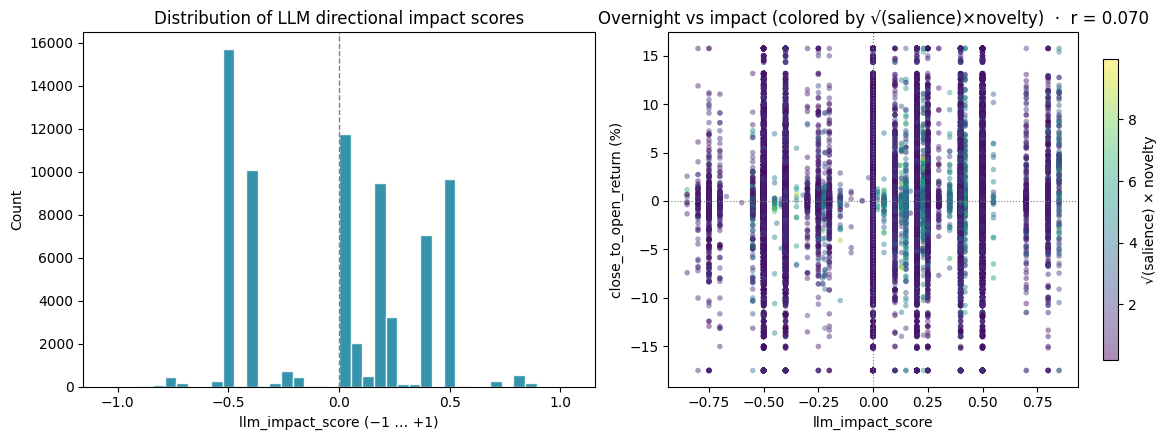

In [133]:
# ── LLM impact score: distribution + vs overnight return ─────────────────────
# Prefers `signal_df["llm_impact_score"]` from Stage 2; if missing (e.g. you re-ran the
# cache-only intent cell), loads scores from the same pickle as Stage 2.

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if "llm_impact_score" not in signal_df.columns:
    _impact_pkl = nh.dev_scoped_cache_path(
        Path("./pkl_cache/llm_impact_score_project_spec_turns.pkl"),
        DEV_TICKERS,
    )
    if not _impact_pkl.is_file():
        raise RuntimeError(
            f"`llm_impact_score` not on signal_df and no cache file at {_impact_pkl}. "
            "Run the LLM Stage 2 (impact) cell first."
        )
    with open(_impact_pkl, "rb") as f:
        _idc = pickle.load(f)
    signal_df = signal_df.copy()
    signal_df["llm_impact_score"] = signal_df["sentence"].map(lambda s: _idc.get(s))
    print(
        f"Attached llm_impact_score from {_impact_pkl.name} "
        f"({len(_idc):,} keys in pickle)"
    )

if "close_to_open_return" not in signal_df.columns:
    raise RuntimeError(
        "signal_df has no close_to_open_return — ensure novelty records / merge included it."
    )

_imp = signal_df.dropna(
    subset=[
        "llm_impact_score",
        "close_to_open_return",
        "salience_score",
        "novelty_score",
    ]
).copy()
print(f"Segments with impact + overnight + salience + novelty: {len(_imp):,}")
if _imp.empty:
    raise RuntimeError(
        "No rows with non-null llm_impact_score, close_to_open_return, salience_score, novelty_score. "
        "Re-run Stage 2 impact scoring or check sentence keys vs impact pickle."
    )

_color = np.sqrt(_imp["salience_score"].clip(lower=0)) * _imp["novelty_score"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.hist(_imp["llm_impact_score"], bins=40, range=(-1.05, 1.05), color="#1985A1", edgecolor="white", alpha=0.88)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("llm_impact_score (−1 … +1)")
ax.set_ylabel("Count")
ax.set_title("Distribution of LLM directional impact scores")

ax = axes[1]
sc = ax.scatter(
    _imp["llm_impact_score"],
    _imp["close_to_open_return"] * 100.0,
    alpha=0.45,
    s=16,
    c=_color,
    cmap="viridis",
    edgecolors="none",
)
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.axvline(0, color="gray", ls=":", lw=0.8)
ax.set_xlabel("llm_impact_score")
ax.set_ylabel("close_to_open_return (%)")
if len(_imp) >= 3:
    r = _imp["llm_impact_score"].corr(_imp["close_to_open_return"])
    ax.set_title(f"Overnight vs impact (colored by √(salience)×novelty)  ·  r = {r:.3f}")
else:
    ax.set_title("Overnight vs impact (colored by √(salience)×novelty)")
plt.colorbar(sc, ax=ax, shrink=0.85, label="√(salience) × novelty")

plt.tight_layout()
plt.savefig("llm_impact_vs_overnight.png", dpi=150, bbox_inches="tight")
plt.show()


In [135]:
signal_df
signal_df.to_csv("signal_df.csv")

In [113]:
# ── Apply LLM gate from disk cache only (resume-safe) ─────────────────────────
# Run this if you **stopped the LLM loop early**: the prior cell's `finally` saves
# `intent_cache` to `LLM_INTENT_CACHE`, but `signal_df` is only LLM-filtered after
# the loop assigns `llm_intent_pass`. This cell **reloads the pickle** and rebuilds
# `llm_candidates["llm_intent_pass"]` from cached YES/NO only (no Ollama calls).
#
# Rows whose `sentence` is **not** in the cache are treated as **NO** (excluded).
# Re-run the main LLM cell later to fill gaps; cached keys are skipped on API.

if "LLM_INTENT_CACHE" not in globals():
    raise RuntimeError("Run the Ollama / LLM cell above first (defines LLM_INTENT_CACHE).")

if "llm_candidates" not in globals() or llm_candidates is None or len(llm_candidates) == 0:
    raise RuntimeError(
        "Define llm_candidates first (run the main cell through "
        "`llm_candidates = signal_df.copy()`)."
    )

if LLM_INTENT_CACHE.exists():
    with open(LLM_INTENT_CACHE, "rb") as f:
        _ic_disk = pickle.load(f)
else:
    _ic_disk = {}

_missing = 0
_llm_flags: list[bool] = []
for _, _row in llm_candidates.iterrows():
    _s = _row["sentence"]
    if _s in _ic_disk:
        _llm_flags.append(bool(_ic_disk[_s]))
    else:
        _missing += 1
        _llm_flags.append(False)

llm_candidates = llm_candidates.copy()
llm_candidates["llm_intent_pass"] = _llm_flags
intent_cache = dict(_ic_disk)

_n_keys = len(_ic_disk)
print(
    f"Cache-only gate: {_n_keys:,} keys on disk | "
    f"{len(llm_candidates) - _missing:,} rows with cached LLM | "
    f"{_missing:,} rows missing from cache (treated as NO)"
)
signal_df = llm_candidates[llm_candidates["llm_intent_pass"]].copy()

# If impact scores have been computed before, keep them attached on resume runs.
if "llm_impact_score" not in signal_df.columns:
    _impact_pkl = nh.dev_scoped_cache_path(
        Path("./pkl_cache/llm_impact_score_project_spec_turns.pkl"),
        DEV_TICKERS,
    )
    if _impact_pkl.is_file():
        with open(_impact_pkl, "rb") as f:
            _impact_disk = pickle.load(f)
        signal_df["llm_impact_score"] = signal_df["sentence"].map(lambda s: _impact_disk.get(s))
        print(f"Re-attached llm_impact_score from {_impact_pkl.name} ({len(_impact_disk):,} keys)")

print(f"After LLM gate (cache-only): {len(signal_df):,} segments")
if len(llm_candidates):
    print(f"LLM pass rate (on llm_candidates): {llm_candidates['llm_intent_pass'].mean():.1%}")


Cache-only gate: 84,224 keys on disk | 84,352 rows with cached LLM | 0 rows missing from cache (treated as NO)
After LLM gate (cache-only): 73,140 segments
LLM pass rate (on llm_candidates): 86.7%


In [114]:
signal_df = llm_candidates[llm_candidates["llm_intent_pass"] == True].copy()

print(f"After LLM intent filter: {len(signal_df):,} segments")
print(f"LLM pass rate: {llm_candidates['llm_intent_pass'].mean():.1%}")

After LLM intent filter: 73,140 segments
LLM pass rate: 86.7%


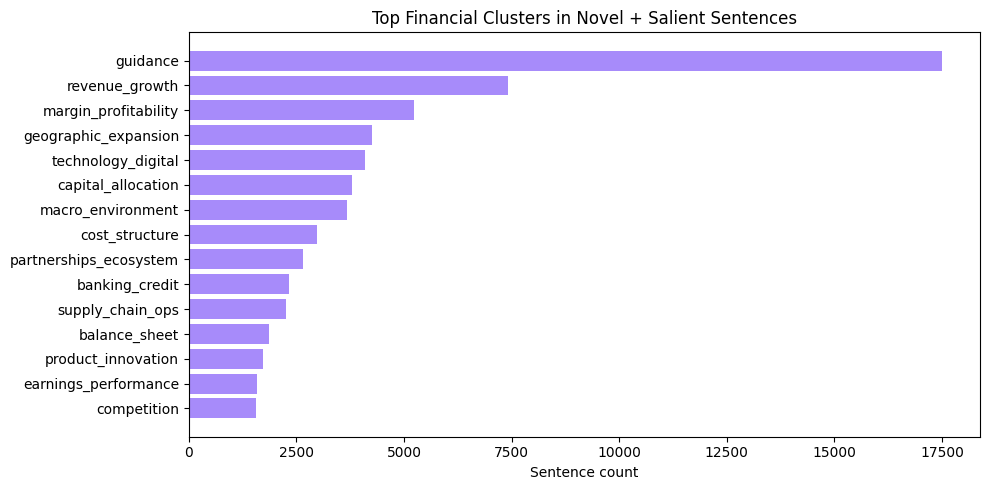


Top 10 clusters in novel sentences:
top_cluster
guidance                  17510
revenue_growth             7411
margin_profitability       5243
geographic_expansion       4261
technology_digital         4086
capital_allocation         3796
macro_environment          3664
cost_structure             2974
partnerships_ecosystem     2657
banking_credit             2337


In [115]:
# What clusters dominate novel sentences?
cluster_counts = (signal_df["top_cluster"]
                  .value_counts()
                  .head(15))

plt.figure(figsize=(10, 5))
plt.barh(cluster_counts.index[::-1], cluster_counts.values[::-1], color="#a78bfa")
plt.title("Top Financial Clusters in Novel + Salient Sentences", fontsize=12)
plt.xlabel("Sentence count")
plt.tight_layout()
plt.savefig("cluster_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nTop 10 clusters in novel sentences:")
print(cluster_counts.head(10).to_string())


In [116]:
# Example: most novel + salient segments
print("=== Top 10 Most Novel + Salient Segments ===\n")
top_examples = (signal_df
                .sort_values(["novelty_score", "salience_score"], ascending=False)
                .head(10))

for _, row in top_examples.iterrows():
    tid = int(row['transcriptid'])
    ci = int(row.get('chunk_index', -1)) if pd.notna(row.get('chunk_index', np.nan)) else -1
    print(f"Ticker : {row['ticker']}  |  Quarter: {row['quarter_str']} | Transcript: {tid} | Chunk: {ci}")
    print(f"Novelty: {row['novelty_score']:.3f}  |  Salience: {row['salience_score']:.3f}  |  Cluster: {row['top_cluster']}")

    # Show chunk parts (context + exec) when available; else fall back to the stored segment text.
    ctx = ''
    ex = ''
    if ci >= 0:
        ctx_list = CONTEXT_TEXT_BY_TID.get(tid)
        ex_list = EXEC_TEXT_BY_TID.get(tid)
        if isinstance(ctx_list, list) and ci < len(ctx_list):
            ctx = str(ctx_list[ci])
        if isinstance(ex_list, list) and ci < len(ex_list):
            ex = str(ex_list[ci])

    if ctx or ex:
        if ctx:
            print(f"Context: {ctx[:400]}...")
        if ex:
            print(f"Exec   : {ex[:400]}...")
    else:
        print(f"Text   : {str(row['sentence'])[:800]}...")
    print()


=== Top 10 Most Novel + Salient Segments ===

Ticker : WFC  |  Quarter: 2017Q4 | Transcript: 1313430 | Chunk: 108
Novelty: 0.980  |  Salience: 4.000  |  Cluster: regulatory_legal
Text   : And when do you expect that you might be able to get out of this consent order?...

Ticker : NFLX  |  Quarter: 2016Q1 | Transcript: 919375 | Chunk: 41
Novelty: 0.947  |  Salience: 1.400  |  Cluster: geographic_expansion
Context: Are you guys -- you are participating the T-Mobile in their program. Are you going to work with Verizon on I think they call it free V announced today?...
Exec   : I don't know enough of the details of Free V. But generally great thing what T-Mobile is doing is making unlimited video consumption a possibility, with freedom from worry about the data caps. And the quick profile from the customer's standpoint on is they only get DVD quality on their 4- or 5-inch screen, which when you look at the DVD quality, it's actually very, very good. But that's a really u...

Ticker : MRK  

In [117]:
signal_df

,ticker,quarter_str,fiscal_year,transcriptid,close_to_open_return,sentence,chunk_index,novelty_score,cosine_sim,novelty_mode,salience_score,top_cluster,cluster_breakdown,trailing_unique_analysts_90d,llm_intent_pass
0,AAPL,2011Q1,2011,92362.0,0.022604,"Thank you. Good afternoon, and thanks for join...",1,0.364330,0.635670,full_turns,10.900,margin_profitability,"{""guidance"": 2.7, ""earnings_performance"": 2.7,...",29,True
1,AAPL,2011Q1,2011,92362.0,0.022604,"Thank you, Nancy. Thank you for joining us. We...",2,0.259547,0.740453,full_turns,87.820,guidance,"{""guidance"": 22.8, ""earnings_performance"": 12....",205,True
3,AAPL,2011Q1,2011,92362.0,0.022604,"As I mentioned on the last quarter's call, we ...",6,0.343207,0.656793,full_turns,2.480,customer_metrics,"{""guidance"": 0.0, ""earnings_performance"": 0.0,...",0,True
4,AAPL,2011Q1,2011,92362.0,0.022604,"And then I just had one follow up, with regard...",7,0.508103,0.491897,full_turns,0.800,mgmt_signal,"{""guidance"": 0.0, ""earnings_performance"": 0.0,...",0,True
5,AAPL,2011Q1,2011,92362.0,0.022604,Let me take each one of those separately. On i...,11,0.218196,0.781804,full_turns,2.250,revenue_growth,"{""guidance"": 0.0, ""earnings_performance"": 0.0,...",31,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84347,XOM,2024Q4,2024,3296585.0,0.009743,"So the biggest thing that impacted that, as yo...",42,0.439985,0.560015,full_turns,6.250,capital_allocation,"{""guidance"": 1.2, ""earnings_performance"": 0.0,...",23,True
84348,XOM,2024Q4,2024,3296585.0,0.009743,Nothing unique. I mean Pioneer's overall contr...,44,0.351687,0.648313,full_turns,3.000,energy_commodities,"{""guidance"": 0.0, ""earnings_performance"": 0.0,...",4,True
84349,XOM,2024Q4,2024,3296585.0,0.009743,"To stay away from the December questions, let ...",48,0.536535,0.463465,full_turns,7.654,cost_structure,"{""guidance"": 0.0, ""earnings_performance"": 0.0,...",8,True
84350,XOM,2024Q4,2024,3296585.0,0.009743,"Yes. Thanks, Roger. I'll start with the end of...",49,0.438572,0.561428,full_turns,16.062,technology_digital,"{""guidance"": 3.0, ""earnings_performance"": 0.0,...",0,True


In [118]:
signal_df.to_csv("signal_df.csv")

## 5. Cross-market frequency penalty — PDF §3.3 (§4.4 look-ahead note)

When many firms in the same quarter share the same dominant novelty cluster, the topic is more **systemic** than **idiosyncratic**. The memo specifies a **smooth sigmoid** penalty in cross-market frequency (not a hard cliff at 40%); see **`project_specification_rio_zac.pdf`** §3.3. The notebook still uses **quarter × cluster** counts as a practical proxy until a trailing three-month prior window is merged from timestamps.

The penalty is applied at the **cluster × quarter** level: for each quarter, compute the fraction of firms where a given cluster is the dominant novelty cluster. If that fraction exceeds the threshold, reduce the signal weight proportionally.


In [119]:
# PDF §3.3 sigmoid: penalty_mult(f) = 1 / (1 + exp(k * (f - f0)))
MACRO_PENALTY_F0 = 0.40
MACRO_PENALTY_K = 15.0

_n_sig = len(signal_df)
signal_df, cross_section = nh.macro_adjust_signal_pipeline(
    signal_df, penalty_f0=MACRO_PENALTY_F0, penalty_k=MACRO_PENALTY_K
)
print(f"Dropped {_n_sig - len(signal_df):,} rows with missing top_cluster before penalty merge")

print("Systemic topics by quarter (cross-market frequency ≥ threshold):")
systemic = cross_section[cross_section["is_systemic"]].sort_values(
    "cross_market_freq", ascending=False
)
print(systemic[["quarter_str", "top_cluster", "n_firms", "total_firms",
                "cross_market_freq"]].head(20).to_string(index=False))

print("\nSignal score distribution after macro adjustment:")
print(signal_df["adjusted_novelty"].describe().round(4))


Dropped 0 rows with missing top_cluster before penalty merge
Systemic topics by quarter (cross-market frequency ≥ threshold):
quarter_str    top_cluster  n_firms  total_firms  cross_market_freq
     2010Q4  balance_sheet        3            3                1.0
     2019Q1       guidance       40           40                1.0
     2013Q4       guidance       41           41                1.0
     2019Q3       guidance       39           39                1.0
     2019Q4       guidance       40           40                1.0
     2013Q3       guidance       39           39                1.0
     2020Q2       guidance       41           41                1.0
     2013Q2 revenue_growth       41           41                1.0
     2020Q3       guidance       41           41                1.0
     2013Q2       guidance       41           41                1.0
     2012Q4       guidance       41           41                1.0
     2021Q4       guidance       40           40          

In [120]:
# ── Blend LLM directional impact into adjusted_novelty (segment level) ─────────
# Requires `llm_impact_score` on `signal_df` (Stage 2 cell). If you resumed via the
# cache-only intent cell, re-attach from pickle the same way as the impact viz cell.

import pickle
from pathlib import Path

if "llm_impact_score" not in signal_df.columns:
    _ip = nh.dev_scoped_cache_path(
        Path("./pkl_cache/llm_impact_score_project_spec_turns.pkl"),
        DEV_TICKERS,
    )
    if _ip.is_file():
        with open(_ip, "rb") as f:
            _im = pickle.load(f)
        signal_df = signal_df.copy()
        signal_df["llm_impact_score"] = signal_df["sentence"].map(lambda s: _im.get(s))
        print(f"Attached llm_impact_score from {_ip.name} for impact blend")
    else:
        signal_df = signal_df.copy()
        signal_df["llm_impact_score"] = 0.0
        print("No impact cache — llm_impact_score set to 0 (blend = identity)")

_imp = signal_df["llm_impact_score"].fillna(0.0).astype(float)
signal_df["adjusted_novelty_pre_impact"] = signal_df["adjusted_novelty"]
_imp_mult = (1.0 + _imp).clip(lower=0.0)
signal_df["adjusted_novelty"] = signal_df["adjusted_novelty_pre_impact"] * _imp_mult

print("adjusted_novelty_pre_impact:", signal_df["adjusted_novelty_pre_impact"].describe().round(4).to_string())
print("impact multiplier (1+score)_+:", _imp_mult.describe().round(4).to_string())
print("adjusted_novelty (with impact):", signal_df["adjusted_novelty"].describe().round(4).to_string())


## 6. Firm-quarter signal & adjusted novelty — PDF §3.3 Stage 2 + aggregation

Aggregate to the **firm-quarter** level. At the **segment** level (after macro penalty):

```
adjusted_novelty_pre_impact = novelty_score × salience_score × penalty_mult
adjusted_novelty          = adjusted_novelty_pre_impact × max(0, 1 + llm_impact_score)
```

(`llm_impact_score` is in [−1, +1] from Stage 2 Ollama; missing scores are treated as 0 so the multiplier is 1.)

Firm-quarter aggregation then takes **means** over intent-passed segments, e.g.:

```
adjusted_novelty_score(firm, quarter) = mean(adjusted_novelty) over segments
```

We also keep **`mean_llm_impact`** (mean `llm_impact_score`) for tables, plots, and regressions.

We merge **`close_to_open_return`** for the overnight reaction, then attach **`permno`**, **`gvkey`**, **`word_count`**, **`sue`** (I/B/E/S), **`pre_drift`**, and surprise fields from the cleaned **`df`** row for that event. **CAR windows** use winsorized dailies from §1b:

- **`CAR_m1_p1`** = `ret_t-1` + `ret_t0` + `ret_t1` (event window [−1, +1])
- **`CAR_p2_p5`** = `ret_t2` + `ret_t3` + `ret_t4` + `ret_t5` (post window [+2, +5])

Daily `ret_t*` ingredients are dropped after summing to keep the firm-quarter table narrow; re-merge from `df` if you need them in regressions.


In [121]:
# Aggregate to firm-quarter signal
assert "penalty_mult" in signal_df.columns, (
    "penalty_mult missing — run the macro-adjustment merge cell above first."
)
assert "adjusted_novelty_pre_impact" in signal_df.columns, (
    "adjusted_novelty_pre_impact missing — run the LLM impact blend cell (after macro) first."
)
assert "llm_impact_score" in signal_df.columns, (
    "llm_impact_score missing — run Stage 2 impact + blend cells first."
)


firm_quarter_signal = (signal_df
    .groupby(["ticker", "quarter_str", "fiscal_year"])
    .agg(
        mean_novelty                 = ("novelty_score",   "mean"),
        mean_salience                = ("salience_score",  "mean"),
        mean_adjusted_novelty_pre    = ("adjusted_novelty_pre_impact", "mean"),
        mean_adjusted_novelty        = ("adjusted_novelty","mean"),
        mean_llm_impact              = ("llm_impact_score", "mean"),
        n_novel_turns                = ("sentence",        "count"),
        macro_penalty                = ("penalty_mult",    "mean"),
        dominant_cluster             = ("top_cluster",     nh.first_mode),
        close_to_open_return         = ("close_to_open_return", "first"),
    )
    .reset_index()
)

firm_quarter_signal = nh.merge_event_panel_into_firm_quarter(firm_quarter_signal, df)

print(f"Firm-quarter signals: {len(firm_quarter_signal):,}")
print(f"  Panel merge — permno non-null: {firm_quarter_signal['permno'].notna().sum():,}")
print(f"  CAR[-1,+1]  (CAR_m1_p1) non-null: {firm_quarter_signal['CAR_m1_p1'].notna().sum():,}")
print(f"  CAR[+2,+5]  (CAR_p2_p5) non-null: {firm_quarter_signal['CAR_p2_p5'].notna().sum():,}")
print(f"  sue non-null: {firm_quarter_signal['sue'].notna().sum():,}")
print(f"  pre_drift non-null: {firm_quarter_signal['pre_drift'].notna().sum():,}")

print(firm_quarter_signal[
    ["ticker", "quarter_str", "mean_adjusted_novelty_pre", "mean_adjusted_novelty",
     "mean_llm_impact", "close_to_open_return",
     "CAR_m1_p1", "CAR_p2_p5", "sue", "pre_drift"]
].head(10).to_string(index=False))


Firm-quarter signals: 2,245
  Panel merge — permno non-null: 2,245
  CAR[-1,+1]  (CAR_m1_p1) non-null: 2,245
  CAR[+2,+5]  (CAR_p2_p5) non-null: 2,245
  sue non-null: 2,051
  pre_drift non-null: 2,227
ticker quarter_str  mean_adjusted_novelty  close_to_open_return  CAR_m1_p1  CAR_p2_p5      sue  pre_drift
  AAPL      2011Q1               0.275764              0.022604  -0.019682   0.008452  4.54376   0.074653
  AAPL      2011Q2               0.072590              0.036769   0.055777  -0.011220  3.81732  -0.037258
  AAPL      2011Q3               0.130103              0.051134   0.059161   0.042069  5.60151   0.137233
  AAPL      2011Q4               0.186699             -0.049474  -0.055346  -0.001357 -0.39190   0.044239
  AAPL      2012Q1               0.269674              0.080945   0.062978   0.021886  6.57570   0.054246
  AAPL      2012Q2               0.318894              0.098799   0.066531  -0.046214  3.43298  -0.043211
  AAPL      2012Q3               0.305920             -0.

In [122]:
# Rank into quintiles each quarter (cross-sectional signal)
firm_quarter_signal["novelty_quintile"] = (
    firm_quarter_signal
    .groupby("quarter_str")["mean_adjusted_novelty"]
    .transform(nh.quintile_within_quarter)
)

# Clean returns (legacy ±15% clip on overnight — align with §1b winsorization when you standardize)
fqs = firm_quarter_signal.dropna(subset=["close_to_open_return", "novelty_quintile"]).copy()
fqs["close_to_open_return"] = fqs["close_to_open_return"].clip(-0.15, 0.15)
fqs["novelty_quintile"] = fqs["novelty_quintile"].astype(float)

print(f"Observations with returns + quintile: {len(fqs):,}")
print(fqs.groupby("novelty_quintile")["close_to_open_return"].describe())

# Subset with full CAR + SUE for event-study / FE regressions (optional)
fqs_reg = fqs.dropna(subset=["CAR_m1_p1", "CAR_p2_p5", "sue"]).copy()
print(f"\nWith CAR[-1,+1], CAR[+2,+5], and SUE (for regressions): {len(fqs_reg):,}")


Observations with returns + quintile: 2,242
                  count      mean       std       min       25%       50%  \
novelty_quintile                                                            
1.0               465.0  0.004237  0.037888 -0.150000 -0.005800  0.001205   
2.0               446.0  0.001479  0.043563 -0.150000 -0.009450  0.000270   
3.0               437.0 -0.000808  0.039954 -0.150000 -0.008501  0.000296   
4.0               446.0  0.002399  0.036739 -0.136589 -0.007286  0.000000   
5.0               448.0  0.005461  0.038700 -0.150000 -0.009522  0.001099   

                       75%   max  
novelty_quintile                  
1.0               0.007665  0.15  
2.0               0.009600  0.15  
3.0               0.007165  0.15  
4.0               0.007837  0.15  
5.0               0.014515  0.15  

With CAR[-1,+1], CAR[+2,+5], and SUE (for regressions): 2,051


## 6b. Model specification — PDF §7 (regression hooks via `novelty_helpers`)

- **`nh.fit_ols_cluster(formula, data, cluster_col)`** — OLS with clustered covariance (here `cluster_col="quarter_str"` as a coarse calendar proxy; swap to event date when merged).
- **`nh.fetch_ff5_monthly`** — monthly Fama–French 5 + RF (Ken French zip; works without `pandas_datareader`).
- **`nh.ff5_alpha_regression(ls_monthly, factors=...)`** — time-series alpha on a **monthly** long–short return (decimals). Replace the demo series with portfolio returns from your calendar-time sort.

Requires **`statsmodels`** (`pip install statsmodels`).

In [123]:
# --- Clustered OLS on firm-quarter panel ---
_reg = fqs_reg.dropna(
    subset=[
        "CAR_m1_p1",
        "mean_adjusted_novelty",
        "mean_llm_impact",
        "sue",
        "pre_drift",
        "word_count",
    ]
).copy()
_reg["log_wc"] = np.log(_reg["word_count"].clip(lower=1))

try:
    if len(_reg) > 50:
        fit_car = nh.fit_ols_cluster(
            "CAR_m1_p1 ~ mean_adjusted_novelty + mean_llm_impact + sue + pre_drift + log_wc",
            data=_reg,
            cluster_col="quarter_str",
        )
        print(fit_car.summary())
        fit_car_pre = nh.fit_ols_cluster(
            "CAR_m1_p1 ~ mean_adjusted_novelty_pre + mean_llm_impact + sue + pre_drift + log_wc",
            data=_reg,
            cluster_col="quarter_str",
        )
        print("\n--- Same model with pre-impact adjusted novelty (no LLM blend in X) ---")
        print(fit_car_pre.summary())
    else:
        print(f"Skip clustered OLS: only {len(_reg)} complete rows in fqs_reg")
except Exception as ex:
    print("Clustered OLS skipped:", ex)

# --- FF5 template: replace demo_ls with monthly LS portfolio returns ---
try:
    fac = nh.fetch_ff5_monthly(start="2018-01-01", end="2024-12-31")
    demo_ls = pd.Series(0.005, index=fac.index)
    ff_fit = nh.ff5_alpha_regression(demo_ls, factors=fac, excess_returns=False)
    print("\nDemo FF5 monthly intercept (decimal):", float(ff_fit.params["const"]))
except Exception as ex:
    print("FF5 demo skipped:", ex)

                            OLS Regression Results                            
Dep. Variable:              CAR_m1_p1   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     10.87
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           1.46e-06
Time:                        22:38:21   Log-Likelihood:                 2976.5
No. Observations:                2037   AIC:                            -5943.
Df Residuals:                    2032   BIC:                            -5915.
Df Model:                           4                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.08

## 7. Returns around the event — PDF §6.4 (CAR / event supplement; §6.1–6.3 portfolio extension)

The strategy thesis: **high-novelty firms experience a market overreaction** — an initial spike that mean-reverts. We test this by examining close-to-open returns (overnight market reaction) across novelty quintiles.

**Charts:** (1) mean *signed* overnight return by quintile; (2) mean **absolute** overnight return by quintile (typical magnitude of the move, ignoring direction); (3) cumulative long Q1 / short Q5.

The short signal targets **Quintile 5** (highest novelty) — firms discussing something genuinely new that the market overprices on the announcement.


Firm-quarters in fqs with matching daily returns: 2,242 (of 2,242 in fqs)


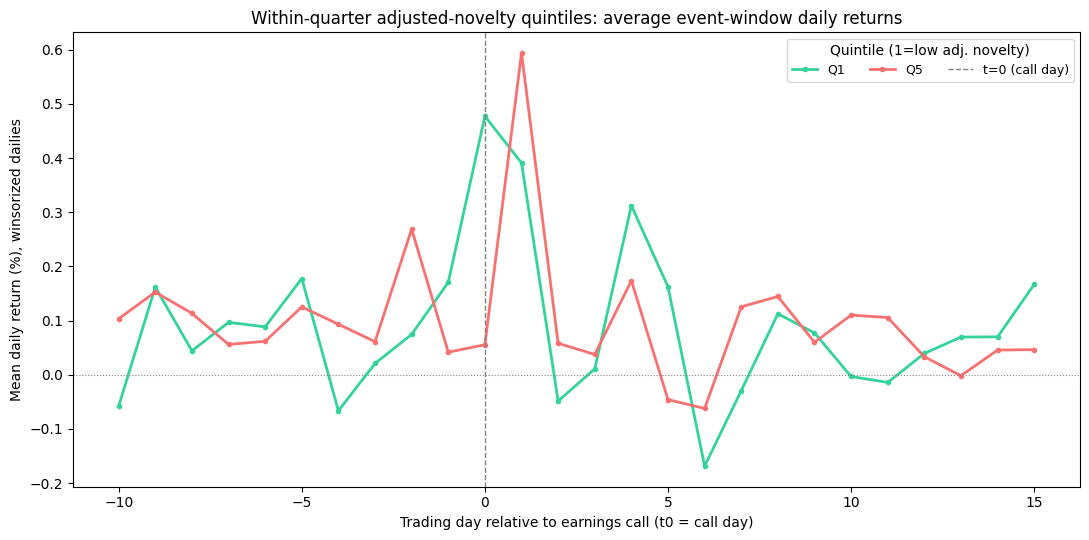

In [124]:
# ── Event-time daily returns by novelty quintile (t−10 … t+15) ───────────────
# `nh.merge_event_panel_into_firm_quarter` drops raw `ret_t*` after forming CARs;
# merge winsorized dailies back from `df` for this path chart.

import matplotlib.pyplot as plt

RET_EVENT_BAND = [f"ret_t{j}" for j in list(range(-10, 0)) + list(range(0, 16))]
_missing = [c for c in RET_EVENT_BAND if c not in df.columns]
if _missing:
    raise RuntimeError(f"df missing return columns (run §1b pipeline first): {_missing[:6]}")

_panel = df[["ticker", "quarter_str"] + RET_EVENT_BAND].drop_duplicates(
    ["ticker", "quarter_str"], keep="last"
)
fqs_daily = fqs.merge(_panel, on=["ticker", "quarter_str"], how="inner")
by_q = fqs_daily.groupby("novelty_quintile")[RET_EVENT_BAND].mean()
days = list(range(-10, 16))

print(
    f"Firm-quarters in fqs with matching daily returns: {len(fqs_daily):,} "
    f"(of {len(fqs):,} in fqs)"
)

fig_ev, ax_ev = plt.subplots(figsize=(11, 5.5))
colors_q = {1.0: "#34d399", 2.0: "#60a5fa", 3.0: "#f5a623", 4.0: "#fb923c", 5.0: "#f87171"}
for q in sorted(by_q.index[[0,4]].dropna(), key=lambda x: float(x)):
    ax_ev.plot(
        days,
        by_q.loc[q].values * 100.0,
        marker="o",
        ms=3,
        lw=2,
        color=colors_q.get(float(q), "#888888"),
        label=f"Q{int(float(q))}",
    )

ax_ev.axvline(0, color="gray", ls="--", lw=1, label="t=0 (call day)")
ax_ev.axhline(0, color="gray", ls=":", lw=0.8)
ax_ev.set_xlabel("Trading day relative to earnings call (t0 = call day)")
ax_ev.set_ylabel("Mean daily return (%), winsorized dailies")
ax_ev.set_title(
    "Within-quarter adjusted-novelty quintiles: average event-window daily returns"
)
ax_ev.legend(title="Quintile (1=low adj. novelty)", ncol=3, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("quintile_event_time_returns.png", dpi=150, bbox_inches="tight")
plt.show()


In [125]:
# (removed debug fragment)

Index([1.0, 5.0], dtype='float64', name='novelty_quintile')

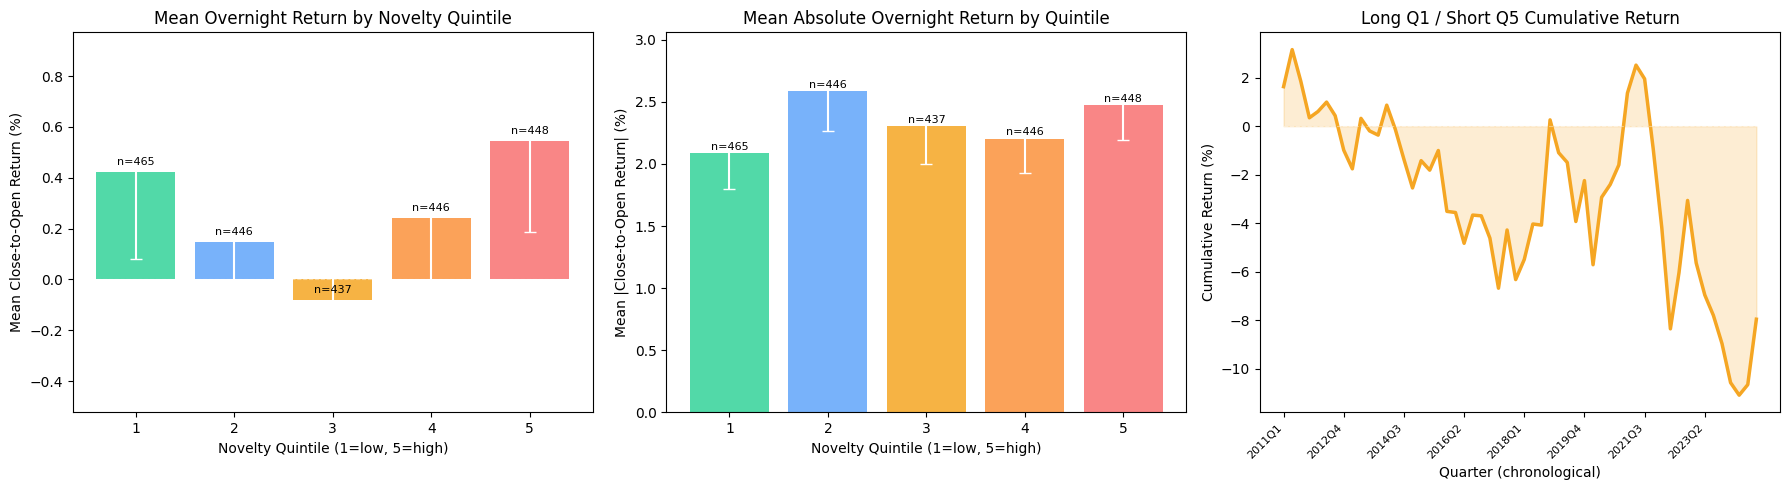

In [126]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Mean signed return by quintile ─────────────────────────────────────────
quintile_returns = (fqs.groupby("novelty_quintile")["close_to_open_return"]
                    .agg(["mean","sem","count"])
                    .reset_index())

colors = ["#34d399","#60a5fa","#f5a623","#fb923c","#f87171"]
ax = axes[0, 0]
bars = ax.bar(
    quintile_returns["novelty_quintile"],
    quintile_returns["mean"] * 100,
    color=colors,
    alpha=0.85, edgecolor="none"
)
ax.errorbar(
    quintile_returns["novelty_quintile"],
    quintile_returns["mean"] * 100,
    yerr=quintile_returns["sem"] * 100 * 1.96,
    fmt="none", color="white", capsize=4, linewidth=1.5
)
ax.axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Novelty Quintile (1=low, 5=high)")
ax.set_ylabel("Mean Close-to-Open Return (%)")
ax.set_title("Mean Overnight Return by Quintile\n(signal = adjusted novelty w/ LLM impact)")
ax.set_xticks([1,2,3,4,5])
for bar, (_, row) in zip(bars, quintile_returns.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"n={int(row['count'])}",
                 ha="center", va="bottom", fontsize=8)

# ── Mean absolute return by quintile ────────────────────────────────────────
quintile_abs = (
    fqs.groupby("novelty_quintile")["close_to_open_return"]
    .agg(
        mean_abs=lambda s: float(s.abs().mean()),
        sem_abs=lambda s: float(s.abs().sem()) if len(s) > 1 else 0.0,
        count="count",
    )
    .reset_index()
)
quintile_abs["sem_abs"] = quintile_abs["sem_abs"].fillna(0.0)

ax = axes[0, 1]
bars_abs = ax.bar(
    quintile_abs["novelty_quintile"],
    quintile_abs["mean_abs"] * 100,
    color=colors,
    alpha=0.85,
    edgecolor="none",
)
ax.errorbar(
    quintile_abs["novelty_quintile"],
    quintile_abs["mean_abs"] * 100,
    yerr=quintile_abs["sem_abs"] * 100 * 1.96,
    fmt="none",
    color="white",
    capsize=4,
    linewidth=1.5,
)
ax.set_xlabel("Novelty Quintile (1=low, 5=high)")
ax.set_ylabel("Mean |Close-to-Open Return| (%)")
ax.set_title("Mean Absolute Overnight Return by Quintile")
ax.set_xticks([1, 2, 3, 4, 5])
for bar, (_, row) in zip(bars_abs, quintile_abs.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"n={int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

# ── Long-short backtest: Q1 long, Q5 short ─────────────────────────────────
fqs_sorted = fqs.sort_values("quarter_str")
ls_by_quarter = (fqs_sorted[fqs_sorted["novelty_quintile"].isin([1,5])]
    .groupby(["quarter_str","novelty_quintile"])["close_to_open_return"]
    .mean()
    .unstack()
    .rename(columns={1:"long_Q1", 5:"short_Q5"})
    .dropna()
)
ls_by_quarter["long_short"] = ls_by_quarter["long_Q1"] - ls_by_quarter["short_Q5"]
ls_by_quarter["cumulative_ls"] = (1 + ls_by_quarter["long_short"]).cumprod() - 1

ax = axes[1, 0]
ax.plot(range(len(ls_by_quarter)),
             ls_by_quarter["cumulative_ls"] * 100,
             color="#f5a623", linewidth=2.5)
ax.fill_between(range(len(ls_by_quarter)),
                      0, ls_by_quarter["cumulative_ls"] * 100,
                      alpha=0.2, color="#f5a623")
ax.axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Quarter (chronological)")
ax.set_ylabel("Cumulative Return (%)")
ax.set_title("Long Q1 / Short Q5 Cumulative Return")
ax.set_xticks(range(0, len(ls_by_quarter), max(1, len(ls_by_quarter)//8)))
ax.set_xticklabels(
    ls_by_quarter.index[::max(1, len(ls_by_quarter)//8)],
    rotation=45, ha="right", fontsize=8
)

# ── Mean LLM impact score by quintile ───────────────────────────────────────
impact_q = (
    fqs.groupby("novelty_quintile")["mean_llm_impact"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)
impact_q["sem"] = impact_q["sem"].fillna(0.0)
ax = axes[1, 1]
bars_i = ax.bar(
    impact_q["novelty_quintile"],
    impact_q["mean"],
    color=colors,
    alpha=0.85,
    edgecolor="none",
)
ax.errorbar(
    impact_q["novelty_quintile"],
    impact_q["mean"],
    yerr=impact_q["sem"] * 1.96,
    fmt="none",
    color="white",
    capsize=4,
    linewidth=1.5,
)
ax.axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Novelty Quintile (1=low, 5=high)")
ax.set_ylabel("Mean LLM impact (−1 … +1)")
ax.set_title("Mean Directional LLM Impact by Quintile")
ax.set_xticks([1, 2, 3, 4, 5])
for bar, (_, row) in zip(bars_i, impact_q.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (0.02 if row["mean"] >= 0 else -0.05),
        f"n={int(row['count'])}",
        ha="center",
        va="bottom" if row["mean"] >= 0 else "top",
        fontsize=8,
    )

plt.tight_layout()
plt.savefig("backtest_results.png", dpi=120, bbox_inches="tight")
plt.show()


In [127]:
# Summary statistics
print("=" * 55)
print("STRATEGY PERFORMANCE SUMMARY")
print("=" * 55)

q1 = fqs[fqs["novelty_quintile"] == 1]["close_to_open_return"]
q5 = fqs[fqs["novelty_quintile"] == 5]["close_to_open_return"]
ls = ls_by_quarter["long_short"]

def sharpe(returns, periods_per_year=4):
    """Annualized Sharpe (quarterly observations)."""
    return (returns.mean() / returns.std()) * (periods_per_year ** 0.5)

print(f"{'Metric':<35} {'Q1 (Low Nov.)':>14} {'Q5 (High Nov.)':>15} {'L-S':>10}")
print("-" * 75)
print(f"{'Mean return':<35} {q1.mean()*100:>13.3f}% {q5.mean()*100:>14.3f}% "
      f"{ls.mean()*100:>9.3f}%")
print(f"{'Std dev':<35} {q1.std()*100:>13.3f}% {q5.std()*100:>14.3f}% "
      f"{ls.std()*100:>9.3f}%")
print(f"{'Hit rate (return > 0)':<35} {(q1>0).mean():>14.1%} {(q5>0).mean():>14.1%} "
      f"{(ls>0).mean():>9.1%}")
print(f"{'Annualized Sharpe':<35} {sharpe(q1):>14.3f} {sharpe(q5):>14.3f} "
      f"{sharpe(ls):>9.3f}")
print(f"{'Observations':<35} {len(q1):>14,} {len(q5):>14,} {len(ls):>9,}")
print("=" * 55)


STRATEGY PERFORMANCE SUMMARY
Metric                               Q1 (Low Nov.)  Q5 (High Nov.)        L-S
---------------------------------------------------------------------------
Mean return                                 0.424%          0.546%    -0.131%
Std dev                                     3.789%          3.870%     1.889%
Hit rate (return > 0)                        55.1%          52.7%     41.1%
Annualized Sharpe                            0.224          0.282    -0.138
Observations                                   465            448        56


## 8. Diagnostics — PDF §5 (EDA-style)

### 8.1 Novelty by Cluster — which clusters drive the short signal?


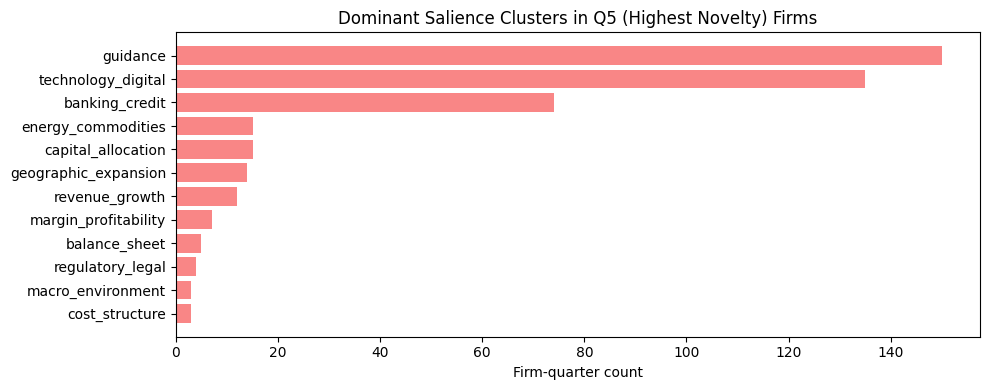

Interpretation: clusters dominating Q5 represent the types of topics
that markets tend to overprice when firms discuss them for the first time.


In [128]:
# Q5 dominant clusters
q5_firms = fqs[fqs["novelty_quintile"] == 5]
q5_clusters = (q5_firms["dominant_cluster"]
               .value_counts()
               .head(12))

plt.figure(figsize=(10, 4))
plt.barh(q5_clusters.index[::-1], q5_clusters.values[::-1], color="#f87171", alpha=0.85)
plt.title("Dominant Salience Clusters in Q5 (Highest Novelty) Firms", fontsize=12)
plt.xlabel("Firm-quarter count")
plt.tight_layout()
plt.savefig("q5_clusters.png", dpi=120, bbox_inches="tight")
plt.show()

print("Interpretation: clusters dominating Q5 represent the types of topics")
print("that markets tend to overprice when firms discuss them for the first time.")


### 8.2 Novelty score vs. return scatter

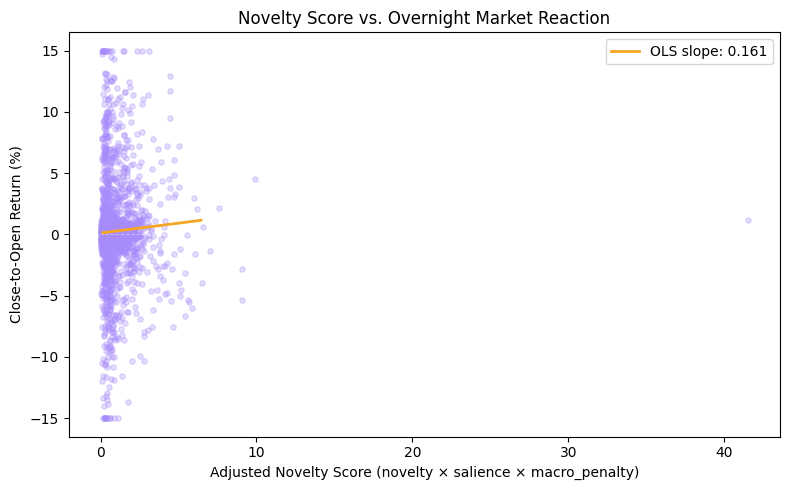

OLS coefficient: 0.1610
Negative slope supports thesis: higher novelty → more overreaction → lower next-day open


In [129]:
plt.figure(figsize=(8, 5))
plt.scatter(
    fqs["mean_adjusted_novelty"],
    fqs["close_to_open_return"] * 100,
    alpha=0.3, s=15, color="#a78bfa"
)

# OLS trend line
from numpy.polynomial import polynomial as P
x = np.sqrt(fqs["mean_adjusted_novelty"].values)
y = fqs["close_to_open_return"].values * 100
mask = np.isfinite(x) & np.isfinite(y)
coef = np.polyfit(x[mask], y[mask], 1)
xline = np.linspace(x[mask].min(), x[mask].max(), 100)
plt.plot(xline, np.polyval(coef, xline), color="#f5a623", linewidth=2,
         label=f"OLS slope: {coef[0]:.3f}")
plt.axhline(0, color="white", linewidth=0.7, linestyle="--", alpha=0.4)
plt.xlabel("Adjusted Novelty Score (novelty × salience × macro_penalty)")
plt.ylabel("Close-to-Open Return (%)")
plt.title("Novelty Score vs. Overnight Market Reaction")
plt.legend()
plt.tight_layout()
plt.savefig("novelty_vs_return.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"OLS coefficient: {coef[0]:.4f}")
print("Negative slope supports thesis: higher novelty → more overreaction → lower next-day open")


## 9. Example signals (illustration)

Pull the top short candidates from the most recent quarter — firms with the highest adjusted novelty scores that passed both the salience and macro filters.


In [130]:
most_recent_q = fqs["quarter_str"].max()
top_shorts = (
    fqs[fqs["quarter_str"] == most_recent_q]
    .nlargest(10, "mean_adjusted_novelty")
    [["ticker","quarter_str","mean_adjusted_novelty_pre","mean_adjusted_novelty",
      "mean_llm_impact","mean_novelty","mean_salience","macro_penalty","dominant_cluster",
      "n_novel_turns","close_to_open_return"]]
)

print(f"Top Short Candidates — {most_recent_q}")
print(top_shorts.to_string(index=False))


Top Short Candidates — 2024Q4
ticker quarter_str  mean_adjusted_novelty  mean_novelty  mean_salience  macro_penalty     dominant_cluster  n_novel_turns  close_to_open_return
   WFC      2024Q4               3.222609      0.454018      11.390400       0.527361       banking_credit             25              0.004591
   MRK      2024Q4               2.065557      0.475672      16.557684       0.236128             guidance             19             -0.005278
   JPM      2024Q4               1.784388      0.468154       8.766267       0.466004       banking_credit             45              0.004094
   BAC      2024Q4               1.718272      0.394475      11.566611       0.401876       banking_credit             36              0.001661
   XOM      2024Q4               1.536671      0.459143      10.037187       0.383132   capital_allocation             32              0.009743
   LLY      2024Q4               1.484326      0.484929      10.543613       0.352418             guidance

In [131]:
# Show the specific novel sentences for the top signal
top_ticker = top_shorts.iloc[0]["ticker"]
top_q      = top_shorts.iloc[0]["quarter_str"]

top_sents = (signal_df[
    (signal_df["ticker"] == top_ticker) &
    (signal_df["quarter_str"] == top_q)
]
.nlargest(5, "adjusted_novelty")
[["sentence","novelty_score","salience_score","top_cluster",
  "adjusted_novelty_pre_impact","adjusted_novelty","llm_impact_score"]])

print(f"\n=== Top novel sentences: {top_ticker} {top_q} ===\n")
for _, row in top_sents.iterrows():
    print(f"Cluster  : {row['top_cluster']}")
    print(
        f"Novelty  : {row['novelty_score']:.3f}  |  Salience: {row['salience_score']:.3f}  "
        f"|  Adj pre-impact: {row['adjusted_novelty_pre_impact']:.4f}  "
        f"|  LLM impact: {row['llm_impact_score']:.3f}  "
        f"|  Adj final: {row['adjusted_novelty']:.4f}"
    )
    print(f"Sentence : {row['sentence'][:200]}")
    print()



=== Top novel sentences: WFC 2024Q4 ===

Cluster  : banking_credit
Novelty  : 0.336  |  Salience: 104.940  |  Adjusted: 33.5623
Sentence : Thank you, Charlie, and good morning, everyone. We are pleased with the results in the third quarter. We again saw good growth in noninterest income across most businesses and expenses were well contr

Cluster  : banking_credit
Novelty  : 0.292  |  Salience: 72.470  |  Adjusted: 20.1812
Sentence : Thanks, John. I'll make some brief comments about our third quarter results and update you on our priorities. I'll then turn the call over to Mike to review our results in more detail before we take y

Cluster  : regulatory_legal
Novelty  : 0.595  |  Salience: 11.000  |  Adjusted: 5.9200
Sentence : Listen, I would -- for anyone who's -- if you have questions on the 2018 Fed consent order, it's very readable. It's something like -- I don't remember exactly, but it's like 5 pages -- 7 pages Mike i

Cluster  : regulatory_legal
Novelty  : 0.675  |  Salience: 

## 10. Discussion — PDF §2 mechanism & implementation gaps

### What this implements from the strategy paper
| Step | Paper | Implementation |
|------|-------|----------------|
| Baseline Build | Per-firm TF-IDF vocabulary profile | ✅ Rolling TF-IDF per firm-quarter |
| Semantic Check | Sentence embeddings + cosine distance | ✅ `EMBEDDING_MODEL_NAME` (default MiniLM; swap to Nomic via config + new cache tag) |
| Text unit | Turn-level (spec) | ⚠️ **Sentence splits** on `full_transcript_text` — `FINAL.csv` has no component/turn rows |
| Empirical panel | `FINAL.csv` + controls | ✅ Returns window + I/B/E/S (`ibes_sue_eps`, surprises); **market cap** still needs merge |
| Intent Verify | LLM binary classifier (YES/NO) | ✅ Salience dictionary (26 clusters, weighted) |
| Macro Adjust | Cross-sectional frequency discount | ✅ Cluster × quarter firm-frequency penalty |

### Why `all-MiniLM-L6-v2` and not FinBERT for embeddings
FinBERT is fine-tuned on financial text for **sentiment classification** (positive/negative/neutral). Its internal representations encode sentiment polarity — the cosine distance between two FinBERT embeddings measures how different their *sentiment* is, not how *semantically novel* one sentence is relative to historical context. Using FinBERT embeddings for novelty detection would flag positive-vs-negative sentence pairs as "novel" even if they discuss identical topics, and would fail to flag genuinely new vocabulary.

`all-MiniLM-L6-v2` is trained on paraphrase and semantic textual similarity tasks — its embedding space preserves meaning such that cosine distance is a valid measure of semantic novelty.

### Limitations & extensions
- **Look-ahead bias:** Ensure baseline only includes transcripts strictly before the event quarter (✅ implemented)
- **Model staleness:** A firm that legitimately pivots will generate persistent false signals — re-weight baseline with recency decay
- **LLM intent filter:** The salience dictionary is a strong proxy but cannot perform the nuanced binary YES/NO classification the paper envisions — a Claude/GPT call on the top-5 novel sentences per firm would add precision
- **Mean reversion horizon T:** This analysis uses the overnight close-to-open return; the paper implies holding for T days — extending to 5/10/20-day cumulative returns is a natural next step
- **Short execution:** Entry timing (after spike confirmation), borrowing costs, and bid-ask spread are not modeled here


In [132]:
signal_df.to_csv("signal_df.csv")